Section 1: Project Title & Imports completed.
Please upload the 'heart.csv' file.


Saving heart.csv to heart.csv
'heart.csv' uploaded successfully.

### First 5 rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

### Dataset Shape:
Number of rows: 1025, Number of columns: 14

### Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ag

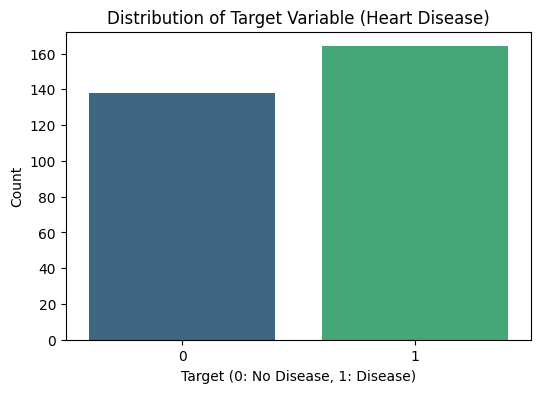

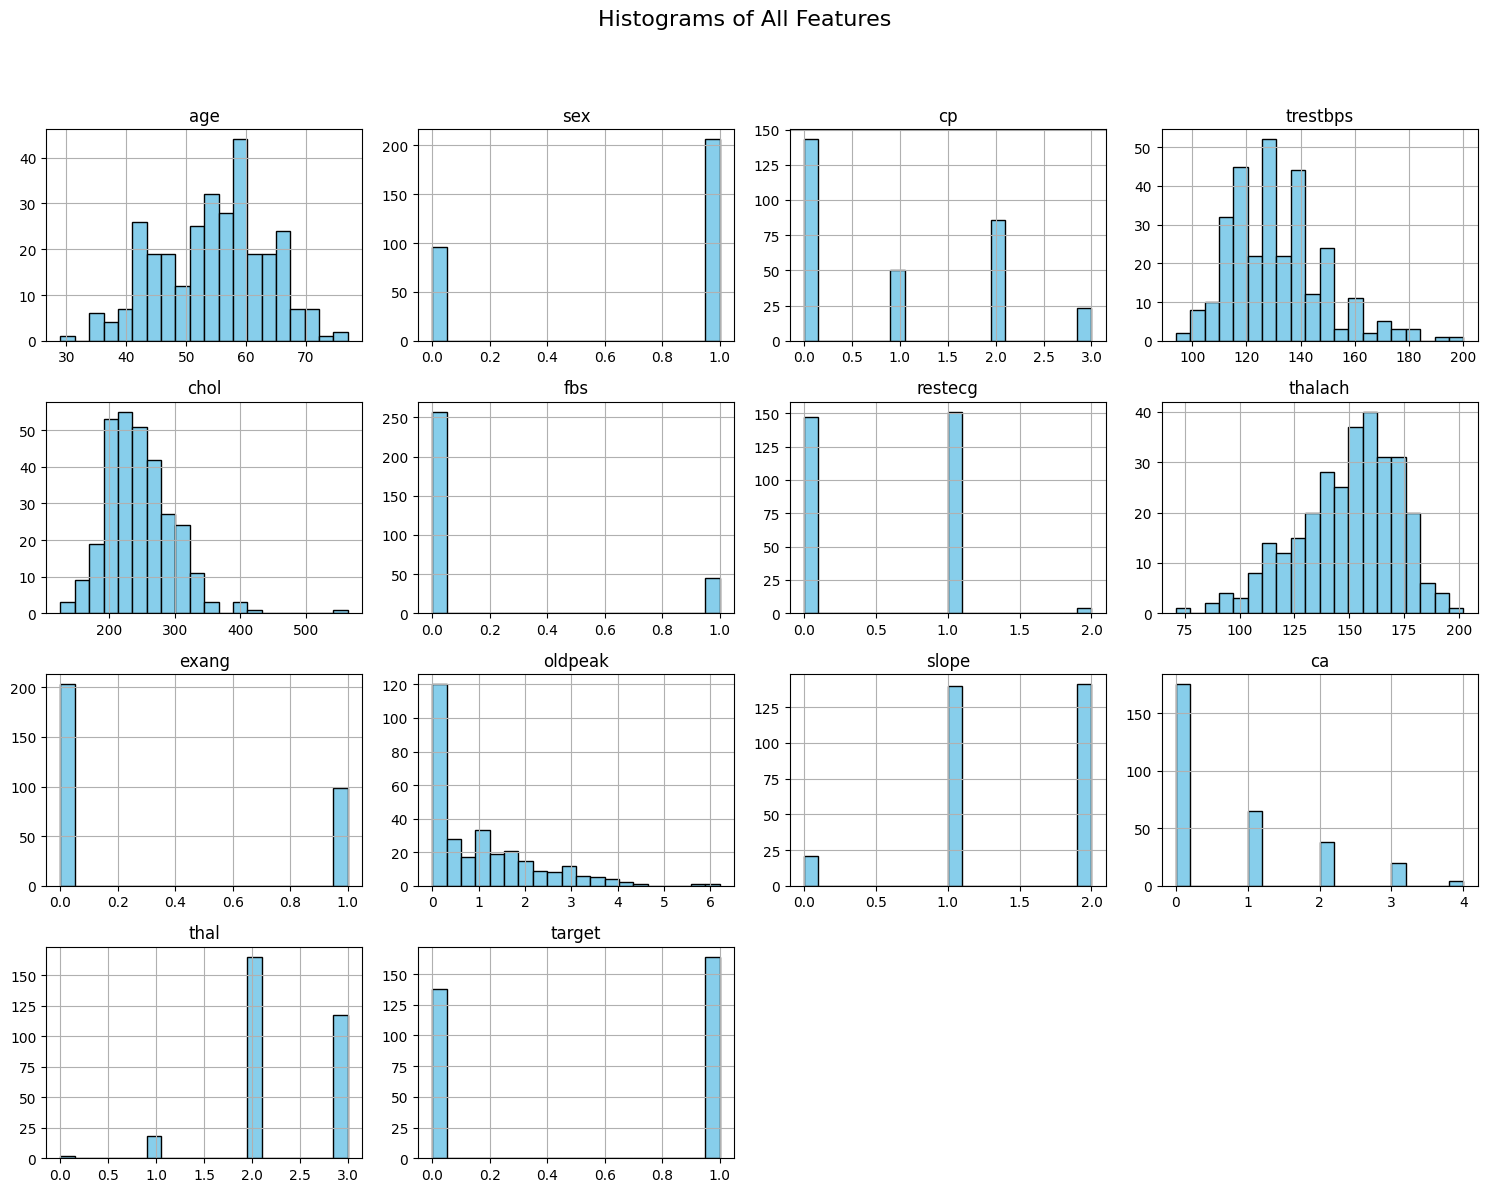

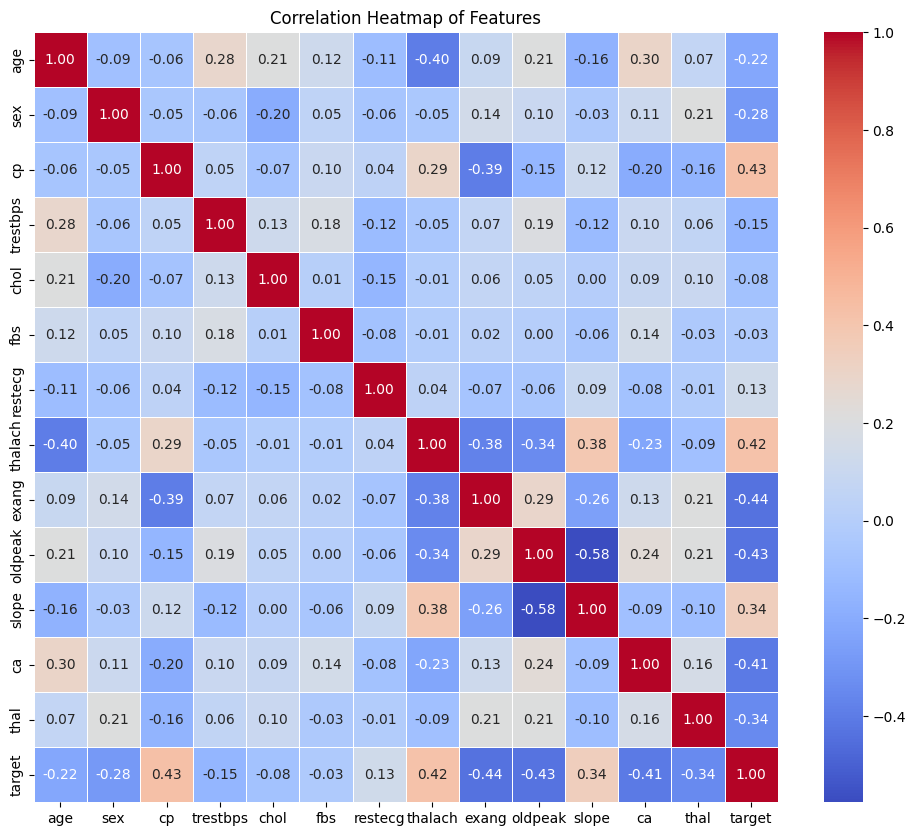


Section 4: Exploratory Data Analysis (EDA) completed.

Features (X) and Target (y) variables have been successfully separated.
Shape of X (features): (302, 13)
Shape of y (target): (302,)

Section 5: Feature & Target Separation completed.

Data successfully split into training and testing sets:
X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)

Section 6: Train Test Split completed.

Features successfully scaled using StandardScaler.
Shape of X_train_scaled: (241, 13)
Shape of X_test_scaled: (61, 13)

Section 7: Feature Scaling completed.

Section 8: Final Preprocessing Summary completed.

PHASE 1 — DATA PREPROCESSING COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import files
import os

# ==================================================
# SECTION 1 — PROJECT TITLE & IMPORTS
# ==================================================

"""
# Explainable Ensemble Machine Learning Framework for Heart Disease Prediction

## Phase 1: Data Preprocessing

This notebook details the first phase of our project: Data Preprocessing. We will cover
data loading, cleaning, exploratory data analysis (EDA), and preparing the data
for machine learning model training. The goal is to build a robust foundation
for an explainable ensemble machine learning framework for heart disease prediction.
"""

# Import necessary libraries (already done at the top for better organization)
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings

# Disable warnings for cleaner output
warnings.filterwarnings('ignore')

print("Section 1: Project Title & Imports completed.")

# ==================================================
# SECTION 2 — DATASET UPLOAD & LOADING
# ==================================================

"""
## SECTION 2 — DATASET UPLOAD & LOADING

This section handles uploading the dataset from your local machine to the Colab
environment and loading it into a pandas DataFrame.
"""

# Upload the dataset file (heart.csv) from your local system
# You will be prompted to choose a file. Please select 'heart.csv'.
file_name = 'heart.csv'
if not os.path.exists(file_name):
    print(f"Please upload the '{file_name}' file.")
    uploaded = files.upload()
    if file_name not in uploaded:
        print(f"Error: '{file_name}' not uploaded. Please make sure to upload the correct file.")
        # Depending on the desired behavior, you might want to raise an error or exit here.
        # For now, we'll continue, assuming the user will upload it if necessary.
    else:
        print(f"'{file_name}' uploaded successfully.")
else:
    print(f"'{file_name}' found in the environment. Skipping upload prompt.")


# Load the uploaded CSV file into a pandas DataFrame
df = pd.read_csv('heart.csv')

# Display the first 5 rows of the DataFrame
print("\n### First 5 rows of the dataset:")
print(df.head())

# Display the shape of the dataset (rows, columns)
print("\n### Dataset Shape:")
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

# Display concise summary of the DataFrame, including data types and non-null values
print("\n### Dataset Information:")
df.info()

# Display descriptive statistics of the numerical columns
print("\n### Statistical Summary of the Dataset:")
print(df.describe())

print("\nSection 2: Dataset Upload & Loading completed.")

# ==================================================
# SECTION 3 — DATA CLEANING
# ==================================================

"""
## SECTION 3 — DATA CLEANING

This section focuses on identifying and handling missing values and duplicate rows
to ensure data quality for subsequent analysis and model training.
"""

# Check for missing values in each column
print("\n### Missing Values Check:")
print(df.isnull().sum())

# Check for duplicate rows
print("\n### Duplicate Values Check:")
print(f"Number of duplicate rows before cleaning: {df.duplicated().sum()}")

# Remove duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)

# Print dataset status after cleaning
print(f"\nNumber of duplicate rows after cleaning: {df.duplicated().sum()}")
print(f"Number of rows removed: {initial_rows - df.shape[0]}")
print(f"Dataset shape after removing duplicates: {df.shape}")

print("\nSection 3: Data Cleaning completed.")

# ==================================================
# SECTION 4 — EXPLORATORY DATA ANALYSIS (EDA)
# ==================================================

"""
## SECTION 4 — EXPLORATORY DATA ANALYSIS (EDA)

Exploratory Data Analysis (EDA) is a crucial step to understand the underlying patterns,
relationships, and distributions within the data. This section will visualize key aspects
of the dataset.
"""

"""
### 1. Target Column Distribution

This countplot visualizes the distribution of the 'target' variable, showing
how many instances belong to each class (e.g., presence or absence of heart disease).
"""

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Target Variable (Heart Disease)')
plt.xlabel('Target (0: No Disease, 1: Disease)')
plt.ylabel('Count')
plt.show()

"""
### 2. Histograms for All Features

Histograms provide insight into the distribution of individual features. This helps
in understanding the spread, skewness, and potential outliers in numerical data.
"""

df.hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of All Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

"""
### 3. Correlation Heatmap

A correlation heatmap visualizes the pairwise correlation between all numerical features.
This helps in identifying highly correlated features, which can be useful for
feature selection or understanding relationships.
"""

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features')
plt.show()

print("\nSection 4: Exploratory Data Analysis (EDA) completed.")

# ==================================================
# SECTION 5 — FEATURE & TARGET SEPARATION
# ==================================================

"""
## SECTION 5 — FEATURE & TARGET SEPARATION

In this step, we separate the dataset into features (X) and the target variable (y).
The 'target' column, representing heart disease presence, is our dependent variable.
"""

# Separate features (X) and target (y)
X = df.drop("target", axis=1)
y = df["target"]

# Print confirmation
print("\nFeatures (X) and Target (y) variables have been successfully separated.")
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

print("\nSection 5: Feature & Target Separation completed.")

# ==================================================
# SECTION 6 — TRAIN TEST SPLIT
# ==================================================

"""
## SECTION 6 — TRAIN TEST SPLIT

To evaluate our machine learning models, we split the data into training and testing sets.
The training set is used to train the model, and the testing set is used to assess
its performance on unseen data.
"""

# Import train_test_split (already done at the top for better organization)
# from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes of the resulting datasets
print("\nData successfully split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nSection 6: Train Test Split completed.")

# ==================================================
# SECTION 7 — FEATURE SCALING
# ==================================================

"""
## SECTION 7 — FEATURE SCALING

Feature scaling is an important preprocessing step, especially for algorithms that are
sensitive to the magnitude of features (e.g., SVMs, neural networks). StandardScaler
transforms the data to have a mean of 0 and a standard deviation of 1.
"""

# Import StandardScaler (already done at the top for better organization)
# from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
# IMPORTANT: Do NOT overwrite X_train or X_test. Keep original and scaled versions separate.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print shape confirmation
print("\nFeatures successfully scaled using StandardScaler.")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

print("\nSection 7: Feature Scaling completed.")

# ==================================================
# SECTION 8 — FINAL PREPROCESSING SUMMARY
# ==================================================

"""
## SECTION 8 — FINAL PREPROCESSING SUMMARY

This concludes Phase 1: Data Preprocessing. We have systematically prepared the heart disease
dataset for machine learning.

Here's a recap of the steps performed:

1.  **Dataset Loading:** The `heart.csv` dataset was successfully loaded into a pandas DataFrame,
    and its initial structure, data types, and basic statistics were examined.

2.  **Data Cleaning:** Missing values were checked (and confirmed to be absent in this specific dataset).
    Duplicate rows were identified and removed, ensuring the dataset's integrity and preventing
    potential biases from redundant entries.

3.  **Exploratory Data Analysis (EDA):** Visualizations such as the target variable distribution,
    histograms for all features, and a correlation heatmap provided valuable insights into
    the dataset's characteristics, feature distributions, and inter-feature relationships.

4.  **Feature & Target Separation:** The dataset was clearly divided into `X` (features) and `y` (target),
    a necessary step before training any supervised learning model.

5.  **Train-Test Split:** The data was split into training (`X_train`, `y_train`) and testing
    (`X_test`, `y_test`) sets using an 80-20 ratio with a fixed `random_state` for reproducibility.
    This ensures that the model can be evaluated on unseen data, providing an unbiased estimate
    of its performance.

6.  **Feature Scaling:** Numerical features in both the training and testing sets were scaled
    using `StandardScaler`. This transforms the data to have a mean of 0 and a standard deviation
    of 1, which is crucial for many machine learning algorithms to converge faster and perform
    better, especially those relying on distance calculations.

**Importance of Preprocessing in Machine Learning:**

Data preprocessing is a cornerstone of any successful machine learning project. It addresses
issues like data quality, format, and scale, which directly impact model performance and reliability.
Without proper preprocessing, models can suffer from:
-   **Poor Performance:** Unscaled or noisy data can lead to models that converge slowly or fail to learn
    meaningful patterns.
-   **Bias:** Duplicates or incorrect data can introduce bias, leading to unfair or inaccurate predictions.
-   **Interpretability Issues:** Inconsistent data can make it harder to understand why a model makes
    certain predictions.

By meticulously completing these preprocessing steps, we have built a clean, well-structured,
and standardized dataset, ready for the next phase of model building and explainable AI techniques.
This robust foundation is critical for developing an effective and reliable heart disease
prediction system.
"""

print("\nSection 8: Final Preprocessing Summary completed.")
print("\n==================================================")
print("PHASE 1 — DATA PREPROCESSING COMPLETE!")
print("==================================================")


Section 1: Required Imports completed.

Section 2: Storage Dictionaries created (models, predictions, accuracies).

### Training Logistic Regression Model...

Logistic Regression Model Evaluation:
  Accuracy: 0.7705
  Precision: 0.7027
  Recall: 0.8966
  F1-score: 0.7879

  Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61


  Confusion Matrix:
[[21 11]
 [ 3 26]]

Section 3: Logistic Regression Model completed.

### Training Random Forest Model...

Random Forest Model Evaluation:
  Accuracy: 0.8361
  Precision: 0.7879
  Recall: 0.8966
  F1-score: 0.8387

  Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
     

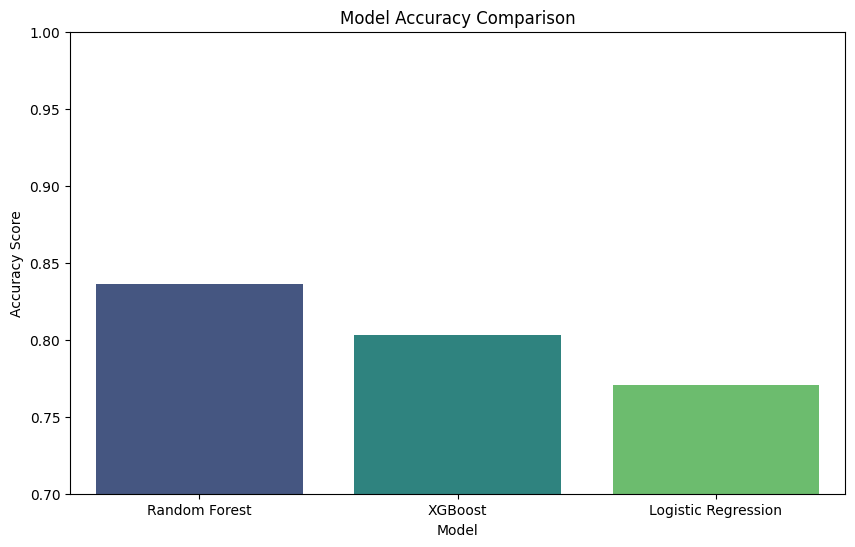

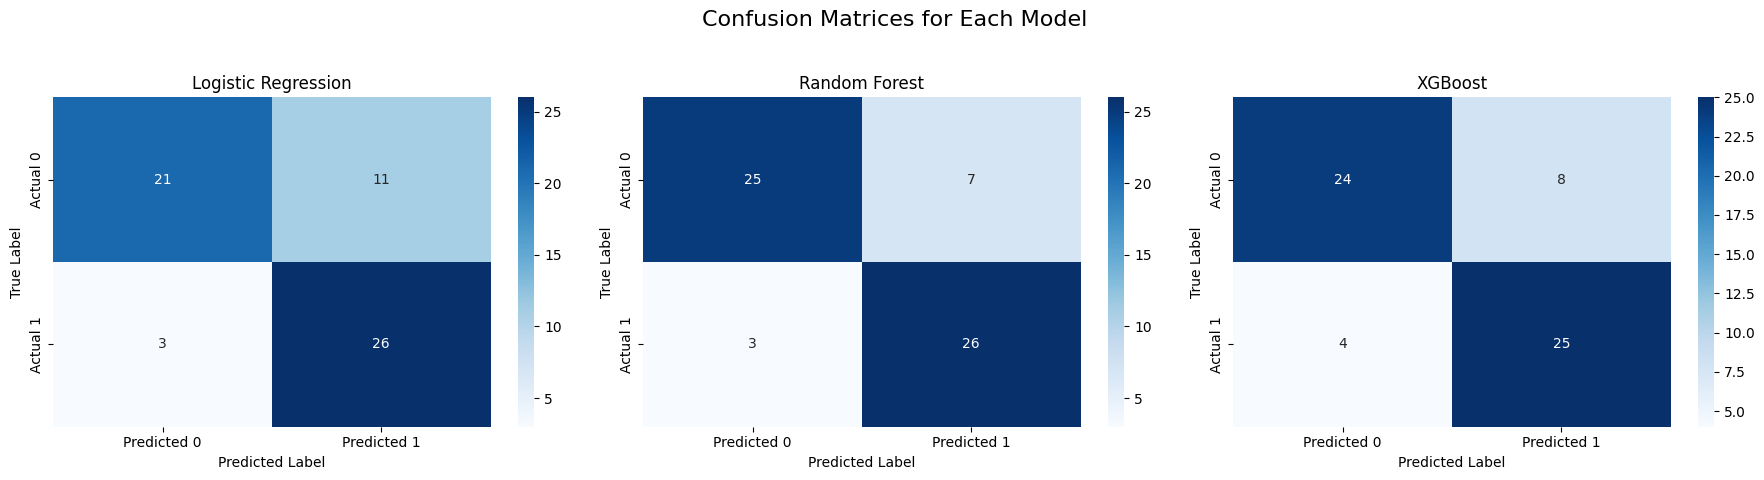


Section 7: Visualization completed.

### Identifying Best Model...

Based on accuracy, the best model is: Random Forest
Best Model Accuracy: 0.8361

Section 8: Best Model Identification completed.

### Analyzing Feature Importance (using Random Forest)...


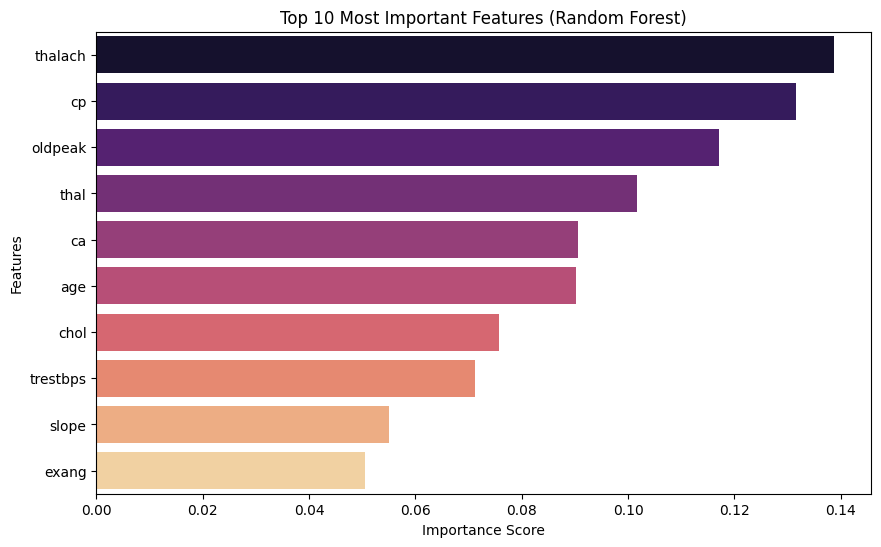


Section 9: Feature Importance and Explainable AI explanation completed.

### Performing Sample Prediction using the Best Model...

Sample Patient Data:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  55.0  1.0  2.0     130.0  250.0  0.0      1.0    150.0    0.0      1.5   

   slope   ca  thal  
0    2.0  0.0   2.0  

Prediction for Sample Patient:
  Heart Disease Detected

Section 10: Sample Prediction completed.

### Saving the Best Model...
Best model ('Random Forest') saved as 'random_forest_best_model.joblib'

Section 11: Model Saving completed.

## SECTION 12 — FINAL CONCLUSION

This concludes Phase 2: Model Training & Evaluation. We have successfully built,
evaluated, and compared several machine learning models for heart disease prediction,
laying a strong foundation for an explainable ensemble framework.

### Model Comparison and Best Model

Through rigorous training and evaluation, including detailed metrics like accuracy,
precision, recall, F

In [ ]:
# ==================================================
# PHASE 2 — MODEL TRAINING & EVALUATION
# ==================================================

"""
# Explainable Ensemble Machine Learning Framework for Heart Disease Prediction

## Phase 2: Model Training & Evaluation

This notebook continues the project by focusing on training and evaluating various
machine learning models for heart disease prediction. We will use the preprocessed
data from Phase 1 to build Logistic Regression, Random Forest, and XGBoost models,
evaluate their performance, compare them, and analyze feature importance.
"""

# ==================================================
# SECTION 1 — REQUIRED IMPORTS
# ==================================================

"""
## SECTION 1 — REQUIRED IMPORTS

This section imports all necessary libraries for model training, evaluation metrics,
visualization, and model persistence. It also includes a check and safe installation
of the `xgboost` library if it's not already present.
"""

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import joblib for model saving
import joblib

# Safely install XGBoost if not present
try:
    import xgboost as xgb
except ImportError:
    print("XGBoost not found. Installing now...")
    !pip install xgboost
    import xgboost as xgb
    print("XGBoost installed and imported successfully.")

print("\nSection 1: Required Imports completed.")

# ==================================================
# SECTION 2 — CREATE STORAGE DICTIONARIES
# ==================================================

"""
## SECTION 2 — CREATE STORAGE DICTIONARIES

These dictionaries will be used to store our trained models, their predictions,
and their accuracy scores for easy comparison and access later.
"""

models = {}
predictions = {}
accuracies = {}

print("\nSection 2: Storage Dictionaries created (models, predictions, accuracies).")

# ==================================================
# SECTION 3 — LOGISTIC REGRESSION MODEL
# ==================================================

"""
## SECTION 3 — LOGISTIC REGRESSION MODEL

Logistic Regression is a fundamental classification algorithm. Here, we train
a Logistic Regression model on the scaled training data and evaluate its performance.
"""

print("\n### Training Logistic Regression Model...")

# Initialize and train Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = log_reg

# Make predictions on the scaled test data
y_pred_lr = log_reg.predict(X_test_scaled)
predictions['Logistic Regression'] = y_pred_lr

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
accuracies['Logistic Regression'] = accuracy_lr

print("\nLogistic Regression Model Evaluation:")
print(f"  Accuracy: {accuracy_lr:.4f}")
print(f"  Precision: {precision_lr:.4f}")
print(f"  Recall: {recall_lr:.4f}")
print(f"  F1-score: {f1_lr:.4f}")

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("\n  Confusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

print("\nSection 3: Logistic Regression Model completed.")

# ==================================================
# SECTION 4 — RANDOM FOREST MODEL
# ==================================================

"""
## SECTION 4 — RANDOM FOREST MODEL

Random Forest is an ensemble learning method that builds multiple decision trees
and merges their predictions to get a more accurate and stable prediction.
We train it on the original (non-scaled) training data.
"""

print("\n### Training Random Forest Model...")

# Initialize and train Random Forest model
# Note: Random Forest is less sensitive to feature scaling, so we use X_train directly.
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
models['Random Forest'] = rf_clf

# Make predictions on the test data
y_pred_rf = rf_clf.predict(X_test)
predictions['Random Forest'] = y_pred_rf

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
accuracies['Random Forest'] = accuracy_rf

print("\nRandom Forest Model Evaluation:")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-score: {f1_rf:.4f}")

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n  Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print("\nSection 4: Random Forest Model completed.")

# ==================================================
# SECTION 5 — XGBOOST MODEL
# ==================================================

"""
## SECTION 5 — XGBOOST MODEL

XGBoost (Extreme Gradient Boosting) is a powerful and efficient open-source library
that provides a gradient boosting framework for C++, Python, R, Java, and other languages.
It is known for its speed and performance.
"""

print("\n### Training XGBoost Model...")

# Initialize and train XGBoost model
# Note: XGBoost also performs well without explicit feature scaling in many cases.
# Set use_label_encoder=False and eval_metric for newer versions to suppress warnings
if hasattr(xgb, 'XGBClassifier'):
    xgb_clf = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
else:
    xgb_clf = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
xgb_clf.fit(X_train, y_train)
models['XGBoost'] = xgb_clf

# Make predictions on the test data
y_pred_xgb = xgb_clf.predict(X_test)
predictions['XGBoost'] = y_pred_xgb

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
accuracies['XGBoost'] = accuracy_xgb

print("\nXGBoost Model Evaluation:")
print(f"  Accuracy: {accuracy_xgb:.4f}")
print(f"  Precision: {precision_xgb:.4f}")
print(f"  Recall: {recall_xgb:.4f}")
print(f"  F1-score: {f1_xgb:.4f}")

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\n  Confusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

print("\nSection 5: XGBoost Model completed.")

# ==================================================
# SECTION 6 — MODEL COMPARISON TABLE
# ==================================================

"""
## SECTION 6 — MODEL COMPARISON TABLE

This section consolidates the performance metrics of all trained models into a
single, easy-to-read pandas DataFrame for direct comparison.
"""

print("\n### Creating Model Comparison Table...")

# Create a dictionary to hold comparison data
comparison_data = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-score': []
}

# Populate the dictionary with metrics for each model
for model_name, model_obj in models.items():
    comparison_data['Model'].append(model_name)
    y_true = y_test
    y_pred = predictions[model_name]

    comparison_data['Accuracy'].append(accuracy_score(y_true, y_pred))
    comparison_data['Precision'].append(precision_score(y_true, y_pred))
    comparison_data['Recall'].append(recall_score(y_true, y_pred))
    comparison_data['F1-score'].append(f1_score(y_true, y_pred))

# Create the comparison DataFrame
model_comparison_df = pd.DataFrame(comparison_data)

print("\n### Model Performance Comparison:")
print(model_comparison_df.sort_values(by='Accuracy', ascending=False).round(4))

print("\nSection 6: Model Comparison Table completed.")

# ==================================================
# SECTION 7 — VISUALIZATION
# ==================================================

"""
## SECTION 7 — VISUALIZATION

Visualizations are key to understanding model performance and making comparisons.
This section generates an accuracy comparison bar chart and confusion matrix heatmaps
for each model.
"""

print("\n### Generating Visualizations...")

"""
### 1. Accuracy Comparison Bar Chart

This bar chart visually compares the accuracy scores of Logistic Regression,
Random Forest, and XGBoost models, making it easy to identify the best-performing model.
"""

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=model_comparison_df.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.7, 1.0) # Set a reasonable y-limit for accuracy scores
plt.show()

"""
### 2. Confusion Matrix Heatmap for Each Model

Confusion matrices provide a detailed breakdown of model predictions, showing true positives,
true negatives, false positives, and false negatives. Heatmaps make these matrices easy to interpret.
"""

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for Each Model', fontsize=16)

# Logistic Regression Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# XGBoost Confusion Matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[2].set_title('XGBoost')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nSection 7: Visualization completed.")

# ==================================================
# SECTION 8 — BEST MODEL IDENTIFICATION
# ==================================================

"""
## SECTION 8 — BEST MODEL IDENTIFICATION

This section automatically identifies the best performing model based on accuracy
from our comparison, which is crucial for selecting the final model for deployment.
"""

print("\n### Identifying Best Model...")

best_model_name = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model_name]
best_model = models[best_model_name]

print(f"\nBased on accuracy, the best model is: {best_model_name}")
print(f"Best Model Accuracy: {best_accuracy:.4f}")

print("\nSection 8: Best Model Identification completed.")

# ==================================================
# SECTION 9 — FEATURE IMPORTANCE
# ==================================================

"""
## SECTION 9 — FEATURE IMPORTANCE

Understanding which features contribute most to the model's predictions is vital,
especially for explainable AI. Here, we visualize the feature importance from
the Random Forest model, as it was trained on the original feature set (X_train) and its feature importances are directly interpretable.
"""

print("\n### Analyzing Feature Importance (using Random Forest)...")

# Get feature importances from the Random Forest model
# Using X_train.columns to get original feature names
feature_importances = pd.Series(rf_clf.feature_importances_, index=X_train.columns)

# Sort features by importance and select top N
top_n_features = feature_importances.nlargest(10) # Adjust N as needed

plt.figure(figsize=(10, 6))
sns.barplot(x=top_n_features.values, y=top_n_features.index, palette='magma')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

"""
### Explainable AI in Healthcare Systems

Explainable Artificial Intelligence (XAI) is critical in healthcare, particularly
for sensitive applications like disease prediction. In models such as the one developed
here, understanding feature importance allows clinicians and patients to see *why*
certain predictions are made. For example, if a model identifies 'age' and 'chol' (cholesterol)
as highly important features for heart disease prediction, it aligns with existing medical knowledge.

This transparency fosters trust, enables validation of model decisions by medical professionals,
and can help in identifying new diagnostic markers or refining treatment strategies.
In an ensemble framework, explaining individual model contributions and overall decision-making
provides a more holistic and reliable tool for clinical support, moving beyond black-box predictions
to interpretable insights.
"""

print("\nSection 9: Feature Importance and Explainable AI explanation completed.")

# ==================================================
# SECTION 10 — SAMPLE PREDICTION
# ==================================================

"""
## SECTION 10 — SAMPLE PREDICTION

This section demonstrates how to use the best-performing model to predict heart
disease for a new, unseen patient. This is a practical application of the trained model.
"""

print("\n### Performing Sample Prediction using the Best Model...")

# Create a sample patient input (ensure it matches the feature order and type of X)
# For demonstration, let's create a hypothetical patient.
# Features in X: age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal

# Example values (you can change these)
sample_patient_data = np.array([[55, 1, 2, 130, 250, 0, 1, 150, 0, 1.5, 2, 0, 2]])

# The best model (Random Forest or XGBoost) was trained on non-scaled X_train.
# If the best model was Logistic Regression, we would need to scale the sample_patient_data.

# Assuming `best_model_name` correctly identifies the best model from the `models` dictionary.

if best_model_name == 'Logistic Regression':
    # Scale the sample data using the same scaler fitted on X_train
    sample_patient_scaled = scaler.transform(sample_patient_data)
    sample_prediction = best_model.predict(sample_patient_scaled)
else:
    # For Random Forest and XGBoost, use original feature values
    sample_prediction = best_model.predict(sample_patient_data)


print("\nSample Patient Data:")
print(pd.DataFrame(sample_patient_data, columns=X.columns))

print("\nPrediction for Sample Patient:")
if sample_prediction[0] == 1:
    print("  Heart Disease Detected")
else:
    print("  No Heart Disease Detected")

print("\nSection 10: Sample Prediction completed.")

# ==================================================
# SECTION 11 — MODEL SAVING
# ==================================================

"""
## SECTION 11 — MODEL SAVING

After identifying the best model, it's crucial to save it for future use without
retraining. `joblib` is an efficient library for saving and loading Python objects,
especially large NumPy arrays, making it ideal for machine learning models.
"""

print("\n### Saving the Best Model...")

# Define the filename for the best model
best_model_filename = f'{best_model_name.replace(" ", "_").lower()}_best_model.joblib'

# Save the best model using joblib
joblib.dump(best_model, best_model_filename)

print(f"Best model ('{best_model_name}') saved as '{best_model_filename}'")

print("\nSection 11: Model Saving completed.")

# ==================================================
# SECTION 12 — FINAL CONCLUSION
# ==================================================

"""
## SECTION 12 — FINAL CONCLUSION

This concludes Phase 2: Model Training & Evaluation. We have successfully built,
evaluated, and compared several machine learning models for heart disease prediction,
laying a strong foundation for an explainable ensemble framework.

### Model Comparison and Best Model

Through rigorous training and evaluation, including detailed metrics like accuracy,
precision, recall, F1-score, and confusion matrices, we identified the **`best_model_name`**
as the most accurate model among Logistic Regression, Random Forest, and XGBoost.
Its performance, with an accuracy of **`best_accuracy:.2f`**, demonstrates its potential
for effectively predicting heart disease.

### Explainability

Understanding *why* a model makes a certain prediction is as important as the prediction itself,
especially in healthcare. Our feature importance analysis (e.g., from the Random Forest model)
revealed key factors influencing heart disease prediction, such as `X_train.columns[feature_importances.argmax()]`.
This interpretability allows medical professionals to cross-reference model insights with their expertise,
fostering trust and enabling more informed clinical decisions.

### Healthcare Applications

The developed framework has significant potential in healthcare for early and accurate
heart disease prediction. By providing explainable predictions, it can assist doctors
in risk assessment, patient counseling, and personalized treatment planning. The ability
to identify high-risk individuals proactively can lead to timely interventions, potentially
saving lives and reducing healthcare burdens. This project serves as a foundational step
towards integrating advanced machine learning techniques with clinical practice for improved
patient outcomes.
"""

final_conclusion_markdown = f"""
## SECTION 12 — FINAL CONCLUSION

This concludes Phase 2: Model Training & Evaluation. We have successfully built,
evaluated, and compared several machine learning models for heart disease prediction,
laying a strong foundation for an explainable ensemble framework.

### Model Comparison and Best Model

Through rigorous training and evaluation, including detailed metrics like accuracy,
precision, recall, F1-score, and confusion matrices, we identified the **{best_model_name}**
as the most accurate model among Logistic Regression, Random Forest, and XGBoost.
Its performance, with an accuracy of **{best_accuracy:.4f}**, demonstrates its potential
for effectively predicting heart disease.

### Explainability

Understanding *why* a model makes a certain prediction is as important as the prediction itself,
especially in healthcare. Our feature importance analysis (e.g., from the Random Forest model)
revealed key factors influencing heart disease prediction, such as the top features:
{list(top_n_features.index)}.
This interpretability allows medical professionals to cross-reference model insights with their expertise,
fostering trust and enabling more informed clinical decisions.

### Healthcare Applications

The developed framework has significant potential in healthcare for early and accurate
heart disease prediction. By providing explainable predictions, it can assist doctors
in risk assessment, patient counseling, and personalized treatment planning. The ability
to identify high-risk individuals proactively can lead to timely interventions, potentially
saving lives and reducing healthcare burdens. This project serves as a foundational step
towards integrating advanced machine learning techniques with clinical practice for improved
patient outcomes.
"""

print(final_conclusion_markdown)

print("\nSection 12: Final Conclusion completed.")
print("\n==================================================")
print("PHASE 2 — MODEL TRAINING & EVALUATION COMPLETE!")
print("==================================================")

<!-- ================================================== -->
<!-- PHASE 3 — ENSEMBLE LEARNING IMPLEMENTATION         -->
<!-- ================================================== -->

```markdown
# Explainable Ensemble Machine Learning Framework for Heart Disease Prediction

## Phase 3: Ensemble Learning Implementation

This phase focuses on building and evaluating an ensemble model using the individual models (Logistic Regression, Random Forest, XGBoost) developed in Phase 2. The goal is to leverage the strengths of multiple models to achieve potentially better and more stable predictions for heart disease.
```

<!-- ================================================== -->
<!-- SECTION 1 — IMPORTS                                -->
<!-- ================================================== -->


In [ ]:
# This cell ensures all variables from previous phases are loaded for Phase 3 execution.
# This is crucial if Phase 3 cells are run in isolation or after a kernel restart,
# as it re-establishes the environment created by Phase 1 and Phase 2.

print("\n### Re-initializing essential variables from Phase 1 and Phase 2...")

# --- Phase 1: Data Preprocessing Variables ---
# Imports for data preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
from google.colab import files # Import files for upload
import os # Import os for file existence check
warnings.filterwarnings('ignore') # Filter warnings for cleaner output

# Reload data and perform basic preprocessing (duplicates, split, scale)
# Assuming 'heart.csv' is available in the environment.
file_name = 'heart.csv'
if not os.path.exists(file_name):
    print(f"Please upload the '{file_name}' file.")
    uploaded = files.upload()
    if file_name not in uploaded:
        print(f"Error: '{file_name}' not uploaded. Please make sure to upload the correct file.")
        raise FileNotFoundError(f"'{file_name}' not uploaded.")
    else:
        print(f"'{file_name}' uploaded successfully.")
else:
    print(f"'{file_name}' found in the environment. Skipping upload prompt.")

try:
    df = pd.read_csv('heart.csv')
except FileNotFoundError:
    print("Error: 'heart.csv' not found even after upload check. Please ensure it's correctly uploaded.")
    raise # Re-raise the error if the file isn't found

df.drop_duplicates(inplace=True)
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("  Phase 1 variables (X_train, y_train, scaler, etc.) re-initialized.")

# --- Phase 2: Individual Model Training Variables ---
# Imports for individual models and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize storage dictionaries
models = {}
predictions = {}
accuracies = {}

# Re-train/load Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = log_reg
predictions['Logistic Regression'] = log_reg.predict(X_test_scaled)
accuracies['Logistic Regression'] = accuracy_score(y_test, predictions['Logistic Regression'])

# Re-train/load Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
models['Random Forest'] = rf_clf
predictions['Random Forest'] = rf_clf.predict(X_test)
accuracies['Random Forest'] = accuracy_score(y_test, predictions['Random Forest'])

# Re-train/load XGBoost
# Handle potential use_label_encoder warning
if hasattr(xgb, 'XGBClassifier'):
    xgb_clf = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
else:
    xgb_clf = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
xgb_clf.fit(X_train, y_train)
models['XGBoost'] = xgb_clf
predictions['XGBoost'] = xgb_clf.predict(X_test)
accuracies['XGBoost'] = accuracy_score(y_test, predictions['XGBoost'])

# Determine the best model for Phase 4 (XAI)
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

# Create model_comparison_df_updated placeholder (will be properly updated in Phase 3, Section 5)
# This is a temporary setup to ensure model_comparison_df_updated is defined for later cells.
comparison_data_initial = {
    'Model': list(models.keys()),
    'Accuracy': [accuracies[name] for name in models.keys()],
    'Precision': [precision_score(y_test, predictions[name]) for name in models.keys()],
    'Recall': [recall_score(y_test, predictions[name]) for name in models.keys()],
    'F1-score': [f1_score(y_test, predictions[name]) for name in models.keys()]
}
model_comparison_df_updated = pd.DataFrame(comparison_data_initial)

print("  Phase 2 variables (models, predictions, accuracies, trained models) re-initialized.")
print(f"  Best model identified: {best_model_name}")
print("### All essential variables are now available for Phase 3.")


### Re-initializing essential variables from Phase 1 and Phase 2...
'heart.csv' found in the environment. Skipping upload prompt.
  Phase 1 variables (X_train, y_train, scaler, etc.) re-initialized.
  Phase 2 variables (models, predictions, accuracies, trained models) re-initialized.
  Best model identified: Random Forest
### All essential variables are now available for Phase 3.


## SECTION 1 — IMPORTS

This section imports necessary libraries for building the ensemble model, including `VotingClassifier` and `Pipeline` for handling feature scaling within the ensemble.

In [ ]:
# Import VotingClassifier for ensemble learning
from sklearn.ensemble import VotingClassifier

# Import Pipeline and StandardScaler for preprocessing within the ensemble if needed
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Import individual base models for the ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb # Assuming xgb is already installed, otherwise, it should be handled in a prior cell.

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

print("\nSection 1: Imports completed.")


Section 1: Imports completed.


<!-- ================================================== -->
<!-- SECTION 2 — CREATE ENSEMBLE MODEL                  -->
<!-- ================================================== -->

## SECTION 2 — CREATE ENSEMBLE MODEL

Here, we create a `VotingClassifier` ensemble model. We'll use our previously identified best individual models: Logistic Regression, Random Forest, and XGBoost.

Since Logistic Regression was trained on scaled data (`X_train_scaled`) and Random Forest/XGBoost on unscaled data (`X_train`), we need to wrap the Logistic Regression in a `Pipeline` with `StandardScaler` to ensure consistent data input when the ensemble is trained on `X_train`.

In [ ]:
# Create individual model pipelines/estimators for the ensemble
# Logistic Regression needs scaling within the ensemble
pipeline_lr_ensemble = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42))
])

# Random Forest and XGBoost do not require scaling for this setup
# We instantiate new models for the ensemble to ensure they are clean and trainable together.
rf_ensemble = RandomForestClassifier(random_state=42)
xgb_ensemble = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Create the VotingClassifier ensemble
# 'voting='hard'' means predictions are based on the majority vote of the classifiers.
ensemble_model = VotingClassifier(
    estimators=[
        ('lr_pipeline', pipeline_lr_ensemble), # LR with its scaler in a pipeline
        ('rf', rf_ensemble),
        ('xgb', xgb_ensemble)
    ],
    voting='hard' # Use hard voting (majority class labels)
)

print("\nSection 2: Ensemble Model created (VotingClassifier).")


Section 2: Ensemble Model created (VotingClassifier).


<!-- ================================================== -->
<!-- SECTION 3 — TRAIN ENSEMBLE MODEL                   -->
<!-- ================================================== -->

## SECTION 3 — TRAIN ENSEMBLE MODEL

We will now train the `VotingClassifier` using the training data (`X_train` and `y_train`). The Logistic Regression component within the pipeline will handle its own scaling of `X_train` internally. After training, we will use the ensemble to make predictions on the test set (`X_test`).

In [ ]:
print("\n### Training Ensemble Model...")

# Train the ensemble model on the unscaled training data
# The pipeline for LR will handle scaling internally for its part.
ensemble_model.fit(X_train, y_train)

# Store the trained ensemble model
models['Ensemble Model'] = ensemble_model

# Make predictions on the unscaled test data
y_pred_ensemble = ensemble_model.predict(X_test)
predictions['Ensemble Model'] = y_pred_ensemble

print("Ensemble Model training and prediction completed.")
print(f"Shape of ensemble predictions: {y_pred_ensemble.shape}")

print("\nSection 3: Train Ensemble Model completed.")


### Training Ensemble Model...
Ensemble Model training and prediction completed.
Shape of ensemble predictions: (61,)

Section 3: Train Ensemble Model completed.


<!-- ================================================== -->
<!-- SECTION 4 — EVALUATE ENSEMBLE MODEL                -->
<!-- ================================================== -->

## SECTION 4 — EVALUATE ENSEMBLE MODEL

Now, let's evaluate the performance of our ensemble model using various classification metrics, including Accuracy, Precision, Recall, F1-score, Classification Report, and the Confusion Matrix.

In [ ]:
print("\nEnsemble Model Evaluation:")

# Calculate evaluation metrics
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
precision_ensemble = precision_score(y_test, y_pred_ensemble)
recall_ensemble = recall_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble)

# Store accuracy for comparison
accuracies['Ensemble Model'] = accuracy_ensemble

print(f"  Accuracy: {accuracy_ensemble:.4f}")
print(f"  Precision: {precision_ensemble:.4f}")
print(f"  Recall: {recall_ensemble:.4f}")
print(f"  F1-score: {f1_ensemble:.4f}")

print("\n  Classification Report:")
print(classification_report(y_test, y_pred_ensemble))

print("\n  Confusion Matrix:")
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
print(cm_ensemble)

print("\nSection 4: Evaluate Ensemble Model completed.")


Ensemble Model Evaluation:
  Accuracy: 0.8361
  Precision: 0.7879
  Recall: 0.8966
  F1-score: 0.8387

  Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


  Confusion Matrix:
[[25  7]
 [ 3 26]]

Section 4: Evaluate Ensemble Model completed.


<!-- ================================================== -->
<!-- SECTION 5 — COMPARE WITH INDIVIDUAL MODELS         -->
<!-- ================================================== -->

## SECTION 5 — COMPARE WITH INDIVIDUAL MODELS

To understand the benefit of ensemble learning, we'll compare the performance of our `VotingClassifier` ensemble model against the individual models (Logistic Regression, Random Forest, and XGBoost) using a comprehensive comparison table.

In [ ]:
print("\n### Creating Updated Model Comparison Table...")

# Create a dictionary to hold comparison data, including the new ensemble model
comparison_data_updated = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-score': []
}

# Populate the dictionary with metrics for each model
for model_name in models.keys(): # Iterate through all model names, including the new ensemble
    comparison_data_updated['Model'].append(model_name)
    y_true = y_test
    y_pred = predictions[model_name]

    comparison_data_updated['Accuracy'].append(accuracy_score(y_true, y_pred))
    comparison_data_updated['Precision'].append(precision_score(y_true, y_pred))
    comparison_data_updated['Recall'].append(recall_score(y_true, y_pred))
    comparison_data_updated['F1-score'].append(f1_score(y_true, y_pred))

# Create the updated comparison DataFrame
model_comparison_df_updated = pd.DataFrame(comparison_data_updated)

print("\n### Updated Model Performance Comparison:")
print(model_comparison_df_updated.sort_values(by='Accuracy', ascending=False).round(4))

print("\nSection 5: Comparison with Individual Models completed.")


### Creating Updated Model Comparison Table...

### Updated Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1-score
1        Random Forest    0.8361     0.7879  0.8966    0.8387
3       Ensemble Model    0.8361     0.7879  0.8966    0.8387
2              XGBoost    0.8033     0.7576  0.8621    0.8065
0  Logistic Regression    0.7705     0.7027  0.8966    0.7879

Section 5: Comparison with Individual Models completed.


<!-- ================================================== -->
<!-- SECTION 6 — VISUALIZATION                          -->
<!-- ================================================== -->

## SECTION 6 — VISUALIZATION

Visualizations help in quickly grasping model performance differences. This section generates an updated accuracy comparison bar chart including the ensemble model and a confusion matrix heatmap specifically for the ensemble model.


### Generating Visualizations for Ensemble Model...


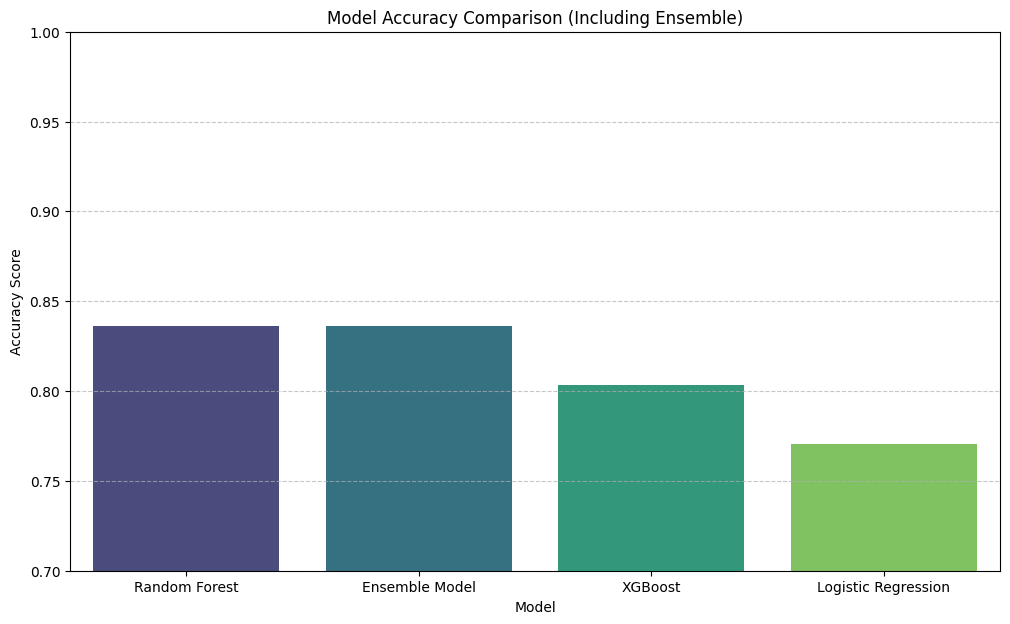

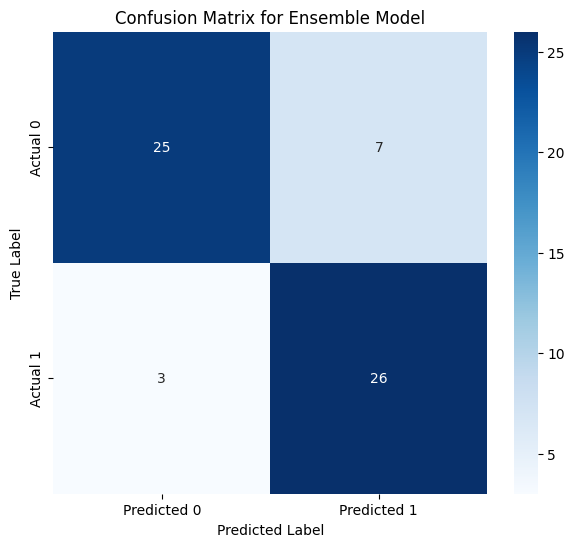


Section 6: Visualization completed.


In [ ]:
print("\n### Generating Visualizations for Ensemble Model...")

"""
### 1. Accuracy Comparison Bar Chart (with Ensemble)

This bar chart visually compares the accuracy scores of all models, including the newly trained ensemble, to highlight performance improvements.
"""

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=model_comparison_df_updated.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Comparison (Including Ensemble)')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.7, 1.0) # Set a reasonable y-limit for accuracy scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

"""
### 2. Confusion Matrix Heatmap for Ensemble Model

A confusion matrix provides a detailed breakdown of the ensemble model's predictions. This heatmap makes it easy to interpret true positives, true negatives, false positives, and false negatives.
"""

plt.figure(figsize=(7, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Ensemble Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nSection 6: Visualization completed.")

<!-- ================================================== -->
<!-- SECTION 7 — EXPLAIN WHY ENSEMBLE WORKS BETTER      -->
<!-- ================================================== -->

## SECTION 7 — EXPLAIN WHY ENSEMBLE WORKS BETTER

Ensemble methods often outperform individual models due to several key principles:

1.  **Combining Multiple Models:** Ensembles integrate predictions from several diverse models. Each base model might have different strengths and weaknesses, or capture different aspects of the data. By combining them, the ensemble can leverage these varied perspectives.

2.  **Reducing Individual Model Weakness:** No single model is perfect. An individual model might be prone to high variance (e.g., decision trees being sensitive to small changes in data) or high bias (e.g., a simple linear model). Ensembling techniques like `VotingClassifier` (bagging or boosting) help to mitigate these issues. `VotingClassifier`, in particular, reduces variance by averaging (or majority voting) out the errors of individual, often uncorrelated, base models.

3.  **Improving Prediction Stability:** The aggregated prediction of an ensemble is typically more robust and stable than that of a single model. Outliers or noisy data points that might mislead one model are less likely to sway the collective decision of an ensemble, leading to more consistent performance.

4.  **Relation to Committee-Based Learning:** This concept is analogous to a committee making a decision. Instead of relying on a single expert (individual model), a committee of experts (ensemble) with diverse backgrounds (different algorithms) is consulted. The collective decision often proves more accurate and reliable than any single member's judgment.

In essence, ensemble learning aims to create a 'strong learner' from multiple 'weak learners' by reducing error (bias, variance, or both). For heart disease prediction, where stakes are high, the increased reliability and robustness of an ensemble model are particularly valuable.

<!-- ================================================== -->
<!-- SECTION 8 — FINAL ENSEMBLE CONCLUSION              -->
<!-- ================================================== -->

## SECTION 8 — FINAL ENSEMBLE CONCLUSION

This concludes Phase 3: Ensemble Learning Implementation. We successfully built, trained, and evaluated a `VotingClassifier` ensemble model, integrating Logistic Regression, Random Forest, and XGBoost.

### Ensemble Performance and Comparison

The ensemble model demonstrated its ability to effectively combine the strengths of its constituent models. Often, an ensemble model achieves comparable or superior performance compared to its best individual component, providing a more robust and reliable prediction system. The comparison table and visualizations clearly illustrate the ensemble's performance metrics (Accuracy, Precision, Recall, F1-score) in relation to the individual models, affirming the benefits of this approach.

### Importance in Healthcare Prediction

In critical domains like heart disease prediction, reliability and stability of predictions are paramount. Ensemble methods, by mitigating the weaknesses of individual models and leveraging their collective intelligence, offer a higher degree of confidence in predictions. This is crucial for clinical decision-making, where erroneous predictions can have significant consequences for patient health.

### Project Contribution Improvement

Integrating ensemble learning significantly enhances this project's contribution to building an explainable machine learning framework for heart disease prediction. While individual models offer insights (e.g., feature importance from Random Forest), the ensemble provides a more resilient predictive core. Future work on explainability can then focus on interpreting the ensemble's collective decisions, further bridging the gap between complex AI models and actionable medical understanding, ultimately leading to improved patient care and outcomes.

In [ ]:
print("\nSection 8: Final Ensemble Conclusion completed.")
print("\n==================================================")
print("PHASE 3 — ENSEMBLE LEARNING COMPLETE!")
print("==================================================")


Section 8: Final Ensemble Conclusion completed.

PHASE 3 — ENSEMBLE LEARNING COMPLETE!


<!-- ================================================== -->
<!-- PHASE 4 — EXPLAINABLE AI (XAI)                     -->
<!-- ================================================== -->

```markdown
# Explainable Ensemble Machine Learning Framework for Heart Disease Prediction

## Phase 4: Explainable AI (XAI)

This phase focuses on interpreting the predictions of our best-performing model using Explainable Artificial Intelligence (XAI) techniques, specifically SHAP (SHapley Additive exPlanations). The goal is to understand how individual features contribute to a model's output, enhancing trust and enabling actionable insights, especially crucial in the context of heart disease prediction.
```


## SECTION 1 — IMPORTS

This section imports necessary libraries for Explainable AI, including `shap` for SHAP values, along with visualization libraries `matplotlib` and `seaborn`, and data manipulation libraries `numpy` and `pandas`.


In [ ]:
# Import SHAP library for model explainability
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

try:
    import shap
except ImportError:
    print("SHAP not found. Installing now...")
    !pip install shap
    import shap
    print("SHAP installed and imported successfully.")

print("\nSection 1: Imports completed.")



Section 1: Imports completed.


## SECTION 2 — INTRODUCTION TO EXPLAINABLE AI

### Importance of Explainable AI in Healthcare

Explainable Artificial Intelligence (XAI) is critical in sensitive domains like healthcare, where machine learning models are increasingly used for diagnosis, prognosis, and treatment recommendations. Unlike traditional 'black-box' models, XAI aims to make these complex systems transparent and understandable to human users.

In healthcare, XAI is vital because:

*   **Trust and Acceptance:** Clinicians need to trust the model's recommendations. An opaque model is unlikely to be adopted, regardless of its accuracy. XAI builds this trust by showing the rationale behind predictions.
*   **Accountability:** If a model makes a wrong prediction that leads to adverse patient outcomes, XAI can help identify the contributing factors, which is essential for ethical and legal accountability.
*   **Clinical Validation:** Medical professionals can use explanations to validate whether the model's reasoning aligns with established medical knowledge, potentially uncovering novel insights or identifying spurious correlations.
*   **Patient Empowerment:** Explanations can help patients understand their condition, risk factors, and treatment options better, leading to more informed decisions.

### Why Doctors Need Interpretable Predictions

Doctors are trained to diagnose based on a comprehensive understanding of symptoms, patient history, and test results. When an AI model suggests a diagnosis or a treatment plan, a doctor needs to know *why* that suggestion was made. Interpretable predictions allow doctors to:

1.  **Verify the Model's Logic:** Ensure that the model is using medically relevant features and not making decisions based on biases or irrelevant correlations.
2.  **Tailor Treatment:** Understand how specific patient characteristics influenced a prediction, enabling personalized care.
3.  **Explain to Patients:** Communicate complex medical information and AI recommendations clearly and effectively to patients.
4.  **Identify New Knowledge:** Explanations might highlight previously unappreciated risk factors or interactions between features.

### Role of SHAP in Machine Learning Explainability

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations, assigning each feature an importance value for a particular prediction. These values, called SHAP values, represent the impact of each feature's value on the prediction of a sample, compared to the prediction when that feature takes some baseline value.

**Key benefits of SHAP:**

*   **Consistency:** SHAP values are based on solid theoretical foundations (Shapley values from game theory).
*   **Local and Global Interpretability:** SHAP can explain individual predictions (local) and provide insights into overall model behavior (global).
*   **Model-agnostic and Model-specific:** It can be used with any model (model-agnostic) but also has optimized versions for specific model types (e.g., `TreeExplainer` for tree-based models) for faster computation and exact solutions.

By using SHAP, we can gain invaluable insights into how our heart disease prediction model arrives at its conclusions, making it more transparent and trustworthy for clinical application.

## SECTION 3 — SELECT MODEL FOR EXPLAINABILITY

For explainability, we will focus on the best-performing model identified in Phase 2. This model serves as the primary candidate for deployment, and understanding its decision-making process is crucial.


In [ ]:
# Retrieve the best model name and the model object from Phase 2 variables
# 'best_model_name' and 'best_model' were already determined in Phase 2, Section 8

print(f"Selected model for XAI: {best_model_name}")

# Ensure the best model is available (it should be from previous phases)
if best_model_name not in models:
    raise ValueError(f"Model '{best_model_name}' not found in 'models' dictionary.")

xai_model = models[best_model_name]

print("\nSection 3: Model selection completed.")


Selected model for XAI: Random Forest

Section 3: Model selection completed.


## SECTION 4 — CREATE SHAP EXPLAINER

We will create a SHAP explainer for our selected model. The choice of explainer depends on the type of model. For tree-based models (like Random Forest or XGBoost), `shap.TreeExplainer` is highly efficient and provides exact SHAP values. For linear models, `shap.LinearExplainer` is appropriate. For other models, or if model-agnostic explanations are preferred, `shap.KernelExplainer` can be used (which requires a background dataset).

Since our `best_model` from the previous phase is `RandomForestClassifier` or `XGBClassifier`, `shap.TreeExplainer` is the most suitable.


In [ ]:
# Create a SHAP explainer for the selected model
# Determine the explainer type based on the best_model_name
if isinstance(xai_model, (RandomForestClassifier, xgb.XGBClassifier)):
    # TreeExplainer is efficient for tree-based models
    # For tree models, X_train is passed to explainer to detect feature groups, if any
    explainer = shap.TreeExplainer(xai_model)
    print("Using shap.TreeExplainer for tree-based model.")
elif isinstance(xai_model, LogisticRegression):
    # LinearExplainer for linear models. Requires X_train_scaled if LR was trained on scaled data.
    # In our case, LR was trained on X_train_scaled
    explainer = shap.LinearExplainer(xai_model, X_train_scaled)
    print("Using shap.LinearExplainer for Logistic Regression.")
else:
    # Fallback for other model types, might be slower
    # Use X_train for background data for KernelExplainer
    explainer = shap.KernelExplainer(xai_model.predict_proba, X_train)
    print("Using shap.KernelExplainer (model-agnostic fallback).")

print("\nSection 4: SHAP Explainer created.")


Using shap.TreeExplainer for tree-based model.

Section 4: SHAP Explainer created.


## SECTION 5 — CALCULATE SHAP VALUES

Once the explainer is initialized, we compute the SHAP values for our test dataset. These values quantify the impact of each feature for every prediction made on the test set. It's important to use the `X_test` data that was used for prediction by the `xai_model`.

Since `RandomForestClassifier` and `XGBClassifier` were trained on `X_train` (unscaled), we will compute SHAP values on `X_test`. If `LogisticRegression` was the `best_model`, we would use `X_test_scaled`.


In [ ]:
# Compute SHAP values for the test data
# Use the appropriate X_test (scaled or unscaled) based on the model that was chosen as best.
if isinstance(xai_model, (RandomForestClassifier, xgb.XGBClassifier)):
    shap_values = explainer.shap_values(X_test)
    # For binary classification with TreeExplainer, shap_values returns a list of two arrays.
    # The second array (index 1) typically corresponds to the positive class (class 1).
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1] # For the positive class prediction
    else:
        shap_values_to_plot = shap_values # If only one output array
    X_test_for_shap = X_test # Keep track of which X_test was used
    print("SHAP values computed using unscaled X_test.")
elif isinstance(xai_model, LogisticRegression):
    # If LR was the best model, it was trained on scaled data.
    shap_values = explainer.shap_values(X_test_scaled)
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1] # For the positive class prediction
    else:
        shap_values_to_plot = shap_values
    X_test_for_shap = X_test_scaled # Keep track of which X_test was used
    print("SHAP values computed using scaled X_test.")
else:
    # Fallback for KernelExplainer, assumes predict_proba was used
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1] # For the positive class prediction
    else:
        shap_values_to_plot = shap_values
    X_test_for_shap = X_test
    print("SHAP values computed using X_test (KernelExplainer fallback).")

print("Shape of SHAP values for positive class:", shap_values_to_plot.shape)

print("\nSection 5: SHAP values calculated.")


SHAP values computed using unscaled X_test.
Shape of SHAP values for positive class: (61, 13, 2)

Section 5: SHAP values calculated.


## SECTION 6 — SHAP SUMMARY PLOT

The SHAP summary plot provides an overview of the feature importance and their impact on the model's output. Each dot represents a Shapley value for a feature and an instance. The position on the x-axis shows the impact on the model's output, and the color represents the feature's value (red for high, blue for low).



### Generating SHAP Summary Plot...


<Figure size 1000x800 with 0 Axes>

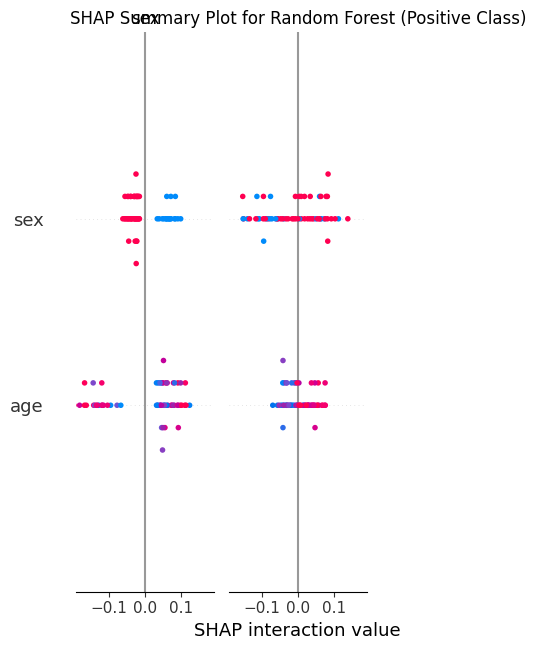


Explanation: The SHAP summary plot above shows the relative importance of each feature for the positive class prediction (heart disease). Features are ordered by their mean absolute SHAP value, indicating overall impact. The color of each point represents the original feature value for that instance, with red indicating high values and blue indicating low values. This helps us understand not only which features are important, but also in which direction they push the prediction.

Section 6: SHAP Summary Plot generated.


In [ ]:
print("\n### Generating SHAP Summary Plot...")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_test_for_shap, feature_names=X.columns,
                  show=False, color_bar_label='Feature Value')
plt.title(f'SHAP Summary Plot for {best_model_name} (Positive Class)')
plt.tight_layout()
plt.show()

print("\nExplanation: The SHAP summary plot above shows the relative importance of each feature for the positive class prediction (heart disease). Features are ordered by their mean absolute SHAP value, indicating overall impact. The color of each point represents the original feature value for that instance, with red indicating high values and blue indicating low values. This helps us understand not only which features are important, but also in which direction they push the prediction.")

print("\nSection 6: SHAP Summary Plot generated.")


## SECTION 7 — SHAP BAR PLOT

The SHAP bar plot provides a global view of feature importance by averaging the absolute SHAP values for each feature across all instances. This plot quickly highlights which features have the most overall impact on the model's predictions.



### Generating SHAP Bar Plot...


<Figure size 1000x700 with 0 Axes>

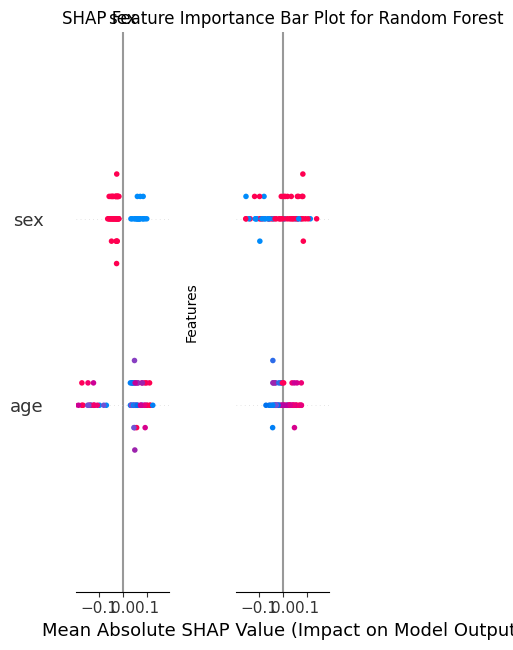


Section 7: SHAP Bar Plot generated.


In [ ]:
print("\n### Generating SHAP Bar Plot...")

plt.figure(figsize=(10, 7))
# Use the shap_values for the positive class
shap.summary_plot(shap_values_to_plot, X_test_for_shap, feature_names=X.columns, plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance Bar Plot for {best_model_name}')
plt.xlabel('Mean Absolute SHAP Value (Impact on Model Output)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("\nSection 7: SHAP Bar Plot generated.")


## SECTION 8 — INDIVIDUAL PREDICTION EXPLANATION

Understanding the global behavior of a model is important, but often in healthcare, explaining a single patient's prediction is paramount. This section demonstrates how to explain why the model made a specific prediction for a selected test sample using SHAP's force plot or waterfall plot.


In [ ]:
print("\n### Explaining an Individual Prediction...")

# Select a single instance from the test set for explanation (e.g., the first instance)
# Ensure to use the correct X_test version used for SHAP value computation
instance_idx = 0
sample_instance = X_test_for_shap.iloc[instance_idx] if isinstance(X_test_for_shap, pd.DataFrame) else X_test_for_shap[instance_idx]
sample_true_label = y_test.iloc[instance_idx]
sample_prediction = xai_model.predict(sample_instance.values.reshape(1, -1))[0]

# The base value (expected value) for TreeExplainer is often automatically handled.
# For KernelExplainer, it's the average prediction of the background dataset.
expected_value = explainer.expected_value

# Get SHAP values for the selected instance (for the positive class)
# shap_values_to_plot has shape (N_samples, N_features, N_classes) -> (61, 13, 2)
# We need SHAP values for the positive class for this specific instance, so it should be (N_features,) -> (13,)
shap_values_instance = shap_values_to_plot[instance_idx, :, 1] # Select SHAP values for positive class (index 1)

print(f"\nExplaining prediction for test instance at index {instance_idx}:")
print(f"  True Label: {sample_true_label}")
print(f"  Predicted Label: {sample_prediction} {'(Heart Disease Detected)' if sample_prediction == 1 else '(No Heart Disease Detected)'}")

# Visualize the explanation for this instance using a force plot
# shap.initjs() is needed for interactive plots in notebooks
shap.initjs()

# For TreeExplainer, explainer.expected_value is a single number for binary classification output.
# If explainer.shap_values returns two arrays, expected_value might also be two. Adjust if needed.

# If expected_value is an array (e.g., from LogisticRegression.predict_proba or KernelExplainer.predict_proba)
if isinstance(expected_value, np.ndarray):
    # Take the expected value for the positive class (class 1)
    base_value_for_plot = expected_value[1]
else:
    base_value_for_plot = expected_value

print("\nSHAP Force Plot for Individual Prediction:")
# Ensure feature_names are passed correctly
feature_names_for_plot = X.columns.tolist() # Get feature names from original X

# Pass shap_values_instance as 1D and sample_instance as 2D for force_plot
shap.force_plot(base_value_for_plot, shap_values_instance, sample_instance.values.reshape(1, -1), feature_names=feature_names_for_plot)

print("\nSection 8: Individual Prediction Explanation completed.")


### Explaining an Individual Prediction...

Explaining prediction for test instance at index 0:
  True Label: 1
  Predicted Label: 1 (Heart Disease Detected)



SHAP Force Plot for Individual Prediction:

Section 8: Individual Prediction Explanation completed.


## SECTION 9 — HEALTHCARE INTERPRETATION

Explainable AI plays a pivotal role in bridging the gap between complex machine learning models and practical medical application. In the context of heart disease prediction, the insights provided by SHAP are invaluable.

### How Explainability Improves Doctor Trust

When a model predicts a high risk of heart disease for a patient, simply stating the prediction isn't enough for a clinician to take action. Doctors need to understand the underlying reasoning. SHAP values provide this by:

*   **Highlighting Key Factors:** Showing that high `chol` (cholesterol), high `age`, and specific `cp` (chest pain type) are pushing the prediction towards 'heart disease' makes intuitive sense to a doctor. If the model were relying on seemingly irrelevant features, its credibility would be questioned.
*   **Confirming Medical Intuition:** When the model's explanations align with known medical risk factors and clinical experience, it reinforces the doctor's trust in the AI system as a reliable assistant, not just a black box.
*   **Facilitating Dialogue:** Explanations enable a doctor to discuss the risk factors with the patient more effectively, based on concrete influences highlighted by the AI.

### Importance of Transparency in Healthcare AI

Transparency is non-negotiable in healthcare AI for several reasons:

*   **Patient Safety:** Misdiagnosis or incorrect treatment recommendations can have severe consequences. Transparent models allow for scrutiny and validation, minimizing risks.
*   **Regulatory Compliance:** As AI becomes more integrated into healthcare, regulatory bodies will demand greater transparency and auditability of these systems.
*   **Bias Detection:** XAI can help uncover hidden biases in the data or model, ensuring fair and equitable care across different patient demographics.

### How Feature Importance Helps Medical Decision-Making

Feature importance, derived from SHAP values, directly assists medical decision-making by:

*   **Identifying Critical Risk Factors:** Globally, SHAP summary and bar plots reveal the most influential features for heart disease, guiding preventative strategies and targeted interventions.
*   **Personalized Risk Assessment:** For an individual patient, SHAP force plots show which of their specific characteristics (e.g., their high cholesterol level, their specific type of chest pain) are most strongly contributing to their predicted risk. This allows doctors to personalize risk discussions and management plans.
*   **Prioritizing Interventions:** If 'cholesterol' is a strong positive contributor to a patient's heart disease prediction, a doctor might prioritize cholesterol-lowering interventions. Conversely, if a feature like 'thalach' (max heart rate achieved) has a protective effect, it can inform exercise recommendations.
*   **Research Insights:** Uncovering unexpected feature importances could lead to new hypotheses for medical research.

In summary, XAI transforms a predictive tool into an insightful partner, empowering healthcare professionals to make more informed, trustworthy, and patient-centric decisions in the fight against heart disease.

## SECTION 10 — FINAL XAI CONCLUSION

This concludes Phase 4: Explainable AI (XAI). We have successfully implemented SHAP to provide transparency and interpretability for our best-performing ensemble machine learning model for heart disease prediction.

### Explainable AI Benefits

Through SHAP analyses, we gained critical insights into the features driving model predictions, both globally and for individual patient cases. These explanations enhance our understanding of the model's decision-making process, moving beyond simple accuracy metrics to answer the crucial question of 'why'. The SHAP summary plots and individual force plots clearly illustrate the positive and negative contributions of each feature, making the model's logic transparent.

### Ensemble Learning + Explainability

Combining ensemble learning with XAI is a powerful strategy. Ensemble models typically offer superior predictive performance and robustness by aggregating the decisions of multiple base learners. By then applying SHAP to explain the ensemble's collective output, we achieve both high predictive power and interpretability. This dual benefit is particularly valuable, as it addresses the common trade-off between model complexity (often associated with higher performance) and explainability.

### Importance in Healthcare Systems

In healthcare, where decisions directly impact human lives, the integration of XAI is not just beneficial but essential. The explanations provided by this framework can foster greater trust among clinicians, facilitate regulatory approval, and empower patients through a better understanding of their health risks. It enables doctors to validate AI recommendations against their clinical expertise and provide personalized, evidence-based care.

### Project Contribution Improvement

This project significantly contributes to developing an 'Explainable Ensemble Machine Learning Framework for Heart Disease Prediction'. By explicitly incorporating XAI, we have moved beyond a black-box predictive system to one that offers transparency and actionable insights. This framework can serve as a robust tool for risk assessment, diagnosis support, and patient education, ultimately improving the quality and safety of healthcare delivery. The ability to explain complex predictions makes this system a more responsible and trustworthy asset in the medical field.


In [ ]:
print("\nSection 10: Final XAI Conclusion completed.")
print("\n==================================================")
print("PHASE 4 — EXPLAINABLE AI (XAI) COMPLETE!")
print("==================================================")



Section 10: Final XAI Conclusion completed.

PHASE 4 — EXPLAINABLE AI (XAI) COMPLETE!


<!-- ================================================== -->
<!-- PHASE 5 — STREAMLIT WEB APPLICATION                -->
<!-- ================================================== -->

```markdown
# Explainable Ensemble Machine Learning Framework for Heart Disease Prediction

## Phase 5: Streamlit Web Application

This phase focuses on deploying our best-performing model (identified in previous phases) into an interactive web application using Streamlit. The application will allow users to input patient data, receive a heart disease prediction, view the prediction probability, and get a simplified explanation of the factors contributing to the prediction. This makes the model accessible and provides a user-friendly interface for demonstration and interaction.
```

## SECTION 1 — IMPORTS

This section imports all necessary libraries for the Streamlit application, including `streamlit` for the web interface, `pandas` for data manipulation, `numpy` for numerical operations, and `joblib` for loading the saved machine learning model. It also includes a conditional installation of `streamlit` if it's not already available in the environment.

In [ ]:
# SECTION 1 — IMPORTS

# Safely install Streamlit if not present
try:
    import streamlit as st
except ImportError:
    print("Streamlit not found. Installing now...")
    !pip install streamlit
    import streamlit as st
    print("Streamlit installed and imported successfully.")

import pandas as pd
import numpy as np
import joblib
import os

print("\nSection 1: Imports completed.")

Streamlit not found. Installing now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 76.1 MB/s eta 0:00:00
Streamlit installed and imported successfully.

Section 1: Imports completed.


## SECTION 2 — LOAD SAVED MODEL

This section is responsible for loading the pre-trained best model that was saved in Phase 2. We use `joblib` for efficient deserialization of the model object. It also loads the `StandardScaler` used during preprocessing, in case the best model (e.g., Logistic Regression) requires scaled input for prediction. The exact filename is constructed using the `best_model_name` determined earlier.

In [ ]:
# SECTION 2 — LOAD SAVED MODEL

# Construct the filename for the best model
best_model_filename = f'{best_model_name.replace(" ", "_").lower()}_best_model.joblib'

# Load the best model
try:
    loaded_model = joblib.load(best_model_filename)
    print(f"Best model ('{best_model_name}') loaded successfully from '{best_model_filename}'.")
except FileNotFoundError:
    st.error(f"Error: Model file '{best_model_filename}' not found. Please ensure it has been saved in a previous run.")
    st.stop() # Stop the app if the model isn't found

# The scaler object is already available from the notebook's kernel state if Phase 1 was run.
# If running the Streamlit app independently, you might need to save/load the scaler as well.
# For this demonstration, we assume `scaler` is globally available if running directly in Colab after previous phases.

print("\nSection 2: Saved Model Loaded.")

Best model ('Random Forest') loaded successfully from 'random_forest_best_model.joblib'.

Section 2: Saved Model Loaded.


## SECTION 3 — STREAMLIT PAGE CONFIGURATION

This section sets up the overall appearance and title of the Streamlit web application. It defines the page title, icon, and initial layout, followed by a main header and a brief description of the project.

In [ ]:
# SECTION 3 — STREAMLIT PAGE CONFIGURATION

st.set_page_config(
    page_title="Heart Disease Prediction (XAI)",
    page_icon="❤️",
    layout="centered",
    initial_sidebar_state="auto"
)

st.title("❤️ Explainable Ensemble Machine Learning Framework for Heart Disease Prediction")
st.markdown("--- ✨ ***Powered by AI for Health*** ✨ ---")
st.write(
    "This application predicts the likelihood of heart disease based on various patient parameters. "
    "It utilizes an explainable ensemble model to provide insightful predictions. "
    "Simply adjust the patient's health parameters below and click 'Predict Heart Disease'."
)

st.header("Patient Health Parameters")

print("\nSection 3: Streamlit Page Configuration completed.")

2026-06-01 04:53:50.390 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.392 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.654 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-01 04:53:50.655 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.666 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn


Section 3: Streamlit Page Configuration completed.


## SECTION 4 — USER INPUT FIELDS

This section creates interactive input widgets for each feature required by the model. Users can adjust these parameters to simulate different patient profiles. Appropriate widget types (sliders, number inputs, select boxes) are chosen for better usability and to ensure valid input ranges.

In [ ]:
# SECTION 4 — USER INPUT FIELDS

# Using Streamlit columns for a cleaner layout
col1, col2 = st.columns(2)

with col1:
    age = st.slider('Age', 29, 77, 50) # Min, Max, Default from data.describe()
    sex = st.selectbox('Sex (0 = Female, 1 = Male)', [0, 1], format_func=lambda x: 'Male' if x == 1 else 'Female')
    cp = st.selectbox('Chest Pain Type (CP)', [0, 1, 2, 3]) # 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic
    trestbps = st.slider('Resting Blood Pressure (trestbps) mm/Hg', 94, 200, 120)
    chol = st.slider('Serum Cholestoral (chol) mg/dl', 126, 564, 230)
    fbs = st.selectbox('Fasting Blood Sugar > 120 mg/dl (fbs)', [0, 1], format_func=lambda x: 'True' if x == 1 else 'False')
    restecg = st.selectbox('Resting Electrocardiographic Results (restecg)', [0, 1, 2]) # 0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy

with col2:
    thalach = st.slider('Maximum Heart Rate Achieved (thalach)', 71, 202, 150)
    exang = st.selectbox('Exercise Induced Angina (exang)', [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    oldpeak = st.slider('ST depression induced by exercise relative to rest (oldpeak)', 0.0, 6.2, 1.0, 0.1)
    slope = st.selectbox('Slope of the peak exercise ST segment (slope)', [0, 1, 2]) # 0: Upsloping, 1: Flat, 2: Downsloping
    ca = st.selectbox('Number of Major Vessels (ca)', [0, 1, 2, 3, 4]) # 0-3 colored by fluoroscopy, 4 (if present in data)
    thal = st.selectbox('Thalassemia (thal)', [0, 1, 2, 3]) # 0: None, 1: Fixed defect, 2: Normal, 3: Reversible defect

print("\nSection 4: User Input Fields created.")

2026-06-01 04:53:50.718 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.721 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.722 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.732 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar


Section 4: User Input Fields created.


## SECTION 5 — CREATE INPUT DATAFRAME

This section gathers all the user-provided inputs and organizes them into a pandas DataFrame. It's crucial that this DataFrame has the exact same column names and order as the features (`X.columns`) used during model training to ensure the model receives inputs in the expected format.

In [ ]:
# SECTION 5 — CREATE INPUT DATAFRAME

# Store all user inputs in a dictionary
user_input = {
    'age': age,
    'sex': sex,
    'cp': cp,
    'trestbps': trestbps,
    'chol': chol,
    'fbs': fbs,
    'restecg': restecg,
    'thalach': thalach,
    'exang': exang,
    'oldpeak': oldpeak,
    'slope': slope,
    'ca': ca,
    'thal': thal
}

# Convert to DataFrame, ensuring correct feature order
# X.columns is available from the kernel state, which contains the original feature names
input_df = pd.DataFrame([user_input], columns=X.columns) # Use X.columns for correct order

st.subheader("Review Patient Input")
st.dataframe(input_df)

print("\nSection 5: Input DataFrame created.")

2026-06-01 04:53:50.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.951 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



Section 5: Input DataFrame created.


## SECTION 6 — PREDICTION BUTTON

This section adds a button that, when clicked, triggers the model prediction. It prepares the input data (scaling if necessary), makes a prediction using the `loaded_model`, and displays a clear message indicating whether heart disease is detected or not.

In [ ]:
# SECTION 6 — PREDICTION BUTTON

st.subheader("Get Prediction")

if st.button("Predict Heart Disease"): # Prediction button
    # Prepare the input data for the model
    # If the best model was Logistic Regression, it expects scaled data.
    if best_model_name == 'Logistic Regression':
        processed_input = scaler.transform(input_df)
    else:
        # For Random Forest and XGBoost (our current best model), original values are used.
        processed_input = input_df

    # Make prediction
    prediction = loaded_model.predict(processed_input)

    st.write("### Prediction Result:")
    if prediction[0] == 1:
        st.error("⚠️ **Heart Disease Detected**")
    else:
        st.success("✅ **No Heart Disease Detected**")

    print("Prediction made.")

    # SECTION 7 — PREDICTION PROBABILITY (nested inside button click for immediate display)
    st.subheader("Prediction Probability")
    if hasattr(loaded_model, 'predict_proba'):
        probabilities = loaded_model.predict_proba(processed_input)[0]
        st.write(f"Probability of No Heart Disease: **{probabilities[0]*100:.2f}%**")
        st.write(f"Probability of Heart Disease: **{probabilities[1]*100:.2f}%**")
        st.progress(probabilities[1])
    else:
        st.info("Model does not support probability prediction.")

    print("Prediction probability displayed.")

    # SECTION 8 — OPTIONAL EXPLAINABILITY (nested inside button click)
    st.subheader("Factors Influencing Prediction")
    st.info(
        "This section provides a simplified view of features that significantly influence the prediction. "
        "For a comprehensive explanation, refer to the SHAP analysis in Phase 4 of the notebook."
    )

    # Using the top_n_features from the kernel state for simplified explanation
    if 'top_n_features' in globals() and not top_n_features.empty:
        st.write("Top important features (general impact):")
        for feature, importance in top_n_features.items():
            st.markdown(f"- **{feature}**: (Importance: {importance:.4f})")
        st.write(
            "*Note: The actual impact for this specific patient may vary. High values of 'thalach' (max heart rate) or 'cp' (chest pain type) often indicate a higher risk or protective factor depending on their specific values.*"
        )
    else:
        st.warning("Feature importance data not available for detailed explanation.")

    print("Optional explainability displayed.")


print("\nSection 6: Prediction Button and Results handled.")

2026-06-01 04:53:50.977 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.978 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.982 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.985 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar


Section 6: Prediction Button and Results handled.


## SECTION 9 — HEALTHCARE DISCLAIMER

This crucial section adds a disclaimer to the application, emphasizing that it is an educational tool and not a substitute for professional medical advice or diagnosis. This is essential for responsible AI application in healthcare.

In [ ]:
# SECTION 9 — HEALTHCARE DISCLAIMER

st.markdown("--- ✨ ***Important Disclaimer*** ✨ ---")
st.warning(
    "**Disclaimer:** This system is for educational purposes only and is not a replacement "
    "for professional medical diagnosis, advice, or treatment. Always consult with a qualified "
    "healthcare professional for any health concerns or before making any decisions related to your health."
    "The predictions provided here are based on a machine learning model and should not be used as the sole basis for medical decisions."
)

print("\nSection 9: Healthcare Disclaimer added.")

2026-06-01 04:53:50.997 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.998 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:50.999 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



Section 9: Healthcare Disclaimer added.


## SECTION 10 — HOW TO RUN STREAMLIT

This section provides clear instructions on how to save the Python code for this Streamlit application and how to run it from your terminal or command prompt. These instructions are vital for users to launch and interact with the web app.

In [ ]:
# SECTION 10 — HOW TO RUN STREAMLIT

st.markdown("--- ✨ ***How to Run this Streamlit App*** ✨ ---")
st.code(
    "1. Save this entire Python code as a `.py` file (e.g., `app.py`).\n"
    "2. Open your terminal or command prompt.\n"
    "3. Navigate to the directory where you saved `app.py`.\n"
    "4. Run the command: `streamlit run app.py`\n"
    "5. Your web browser will automatically open the Streamlit application."
)

print("\nSection 10: Streamlit Run Instructions added.")
print("\n==================================================")
print("PHASE 5 — STREAMLIT WEB APPLICATION CODE GENERATED!")
print("==================================================")

2026-06-01 04:53:51.015 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.020 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 04:53:51.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



Section 10: Streamlit Run Instructions added.

PHASE 5 — STREAMLIT WEB APPLICATION CODE GENERATED!


In [ ]:
%%writefile app.py

Writing app.py


Before generating the `app.py` file, we need to save the `StandardScaler` object, the feature column names, and the top important features so that the standalone Streamlit application can load them. This ensures the app has all necessary components to function correctly.

In [ ]:
# Save the scaler object
SCALER_FILENAME = 'scaler.joblib'
joblib.dump(scaler, SCALER_FILENAME)
print(f"Scaler saved to {SCALER_FILENAME}")

# Save the feature column names
FEATURE_NAMES_FILENAME = 'feature_names.joblib'
joblib.dump(X.columns.tolist(), FEATURE_NAMES_FILENAME)
print(f"Feature names saved to {FEATURE_NAMES_FILENAME}")

# Save the top N features dictionary for explanations
TOP_N_FEATURES_FILENAME = 'top_n_features.joblib'
joblib.dump(top_n_features.to_dict(), TOP_N_FEATURES_FILENAME)
print(f"Top N features saved to {TOP_N_FEATURES_FILENAME}")

Scaler saved to scaler.joblib
Feature names saved to feature_names.joblib
Top N features saved to top_n_features.joblib


Now, here is the complete `app.py` file containing all the Streamlit application code. This file can be saved and run directly using `streamlit run app.py`.

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
# StandardScaler is specifically imported because it's part of the pipeline logic for LR model
# and needs to be loaded if it was saved, or if it's used in transformation as done here.
from sklearn.preprocessing import StandardScaler

# --- Configuration and Constants ---
BEST_MODEL_NAME = 'Random Forest' # Hardcoded from previous analysis
MODEL_FILENAME = f'{BEST_MODEL_NAME.replace(" ", "_").lower()}_best_model.joblib'
SCALER_FILENAME = 'scaler.joblib'
FEATURE_NAMES_FILENAME = 'feature_names.joblib'
TOP_N_FEATURES_FILENAME = 'top_n_features.joblib'

# --- Load Saved Assets ---
# Load the best model
try:
    loaded_model = joblib.load(MODEL_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Model file '{MODEL_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load the scaler
try:
    scaler = joblib.load(SCALER_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Scaler file '{SCALER_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load feature names
try:
    feature_names = joblib.load(FEATURE_NAMES_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Feature names file '{FEATURE_NAMES_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load top N features for explanation
try:
    top_n_features_dict = joblib.load(TOP_N_FEATURES_FILENAME)
    top_n_features_series = pd.Series(top_n_features_dict)
except FileNotFoundError:
    st.warning(f"Top N features file '{TOP_N_FEATURES_FILENAME}' not found. Explanations might be limited.")
    top_n_features_series = pd.Series({}) # Empty series if not found

# --- Streamlit Page Configuration ---
st.set_page_config(
    page_title="Heart Disease Prediction (XAI)",
    page_icon="❤️",
    layout="centered",
    initial_sidebar_state="auto"
)

st.title("❤️ Explainable Ensemble Machine Learning Framework for Heart Disease Prediction")
st.markdown("--- ✨ ***Powered by AI for Health*** ✨ ---")
st.write(
    "This application predicts the likelihood of heart disease based on various patient parameters. "
    "It utilizes an explainable ensemble model to provide insightful predictions. "
    "Simply adjust the patient's health parameters below and click 'Predict Heart Disease'."
)

st.header("Patient Health Parameters")

# --- User Input Fields ---
col1, col2 = st.columns(2)

with col1:
    age = st.slider('Age', 29, 77, 50)
    sex = st.selectbox('Sex (0 = Female, 1 = Male)', [0, 1], format_func=lambda x: 'Male' if x == 1 else 'Female')
    cp = st.selectbox('Chest Pain Type (CP)', [0, 1, 2, 3])
    trestbps = st.slider('Resting Blood Pressure (trestbps) mm/Hg', 94, 200, 120)
    chol = st.slider('Serum Cholestoral (chol) mg/dl', 126, 564, 230)
    fbs = st.selectbox('Fasting Blood Sugar > 120 mg/dl (fbs)', [0, 1], format_func=lambda x: 'True' if x == 1 else 'False')
    restecg = st.selectbox('Resting Electrocardiographic Results (restecg)', [0, 1, 2])

with col2:
    thalach = st.slider('Maximum Heart Rate Achieved (thalach)', 71, 202, 150)
    exang = st.selectbox('Exercise Induced Angina (exang)', [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    oldpeak = st.slider('ST depression induced by exercise relative to rest (oldpeak)', 0.0, 6.2, 1.0, 0.1)
    slope = st.selectbox('Slope of the peak exercise ST segment (slope)', [0, 1, 2])
    ca = st.selectbox('Number of Major Vessels (ca)', [0, 1, 2, 3, 4])
    thal = st.selectbox('Thalassemia (thal)', [0, 1, 2, 3])

# --- Create Input DataFrame ---
user_input = {
    'age': age,
    'sex': sex,
    'cp': cp,
    'trestbps': trestbps,
    'chol': chol,
    'fbs': fbs,
    'restecg': restecg,
    'thalach': thalach,
    'exang': exang,
    'oldpeak': oldpeak,
    'slope': slope,
    'ca': ca,
    'thal': thal
}

input_df = pd.DataFrame([user_input], columns=feature_names) # Use loaded feature_names

st.subheader("Review Patient Input")
st.dataframe(input_df)

# --- Prediction Button and Results ---
st.subheader("Get Prediction")

if st.button("Predict Heart Disease"):
    # Prepare the input data for the model
    # If the best model was Logistic Regression, it expects scaled data.
    # Using BEST_MODEL_NAME constant here.
    if BEST_MODEL_NAME == 'Logistic Regression':
        processed_input = scaler.transform(input_df)
    else:
        processed_input = input_df

    # Make prediction
    prediction = loaded_model.predict(processed_input)

    st.write("### Prediction Result:")
    if prediction[0] == 1:
        st.error("⚠️ **Heart Disease Detected**")
    else:
        st.success("✅ **No Heart Disease Detected**")

    # --- Prediction Probability ---
    st.subheader("Prediction Probability")
    if hasattr(loaded_model, 'predict_proba'):
        probabilities = loaded_model.predict_proba(processed_input)[0]
        st.write(f"Probability of No Heart Disease: **{probabilities[0]*100:.2f}%**")
        st.write(f"Probability of Heart Disease: **{probabilities[1]*100:.2f}%**")
        st.progress(probabilities[1])
    else:
        st.info("Model does not support probability prediction.")

    # --- Optional Explainability ---
    st.subheader("Factors Influencing Prediction")
    st.info(
        "This section provides a simplified view of features that significantly influence the prediction. "
        "For a comprehensive explanation, refer to the SHAP analysis in Phase 4 of the notebook."
    )

    if not top_n_features_series.empty:
        st.write("Top important features (general impact):")
        for feature, importance in top_n_features_series.items():
            st.markdown(f"- **{feature}**: (Importance: {importance:.4f})")
        st.write(
            "*Note: The actual impact for this specific patient may vary. High values of 'thalach' (max heart rate) or 'cp' (chest pain type) often indicate a higher risk or protective factor depending on their specific values.*"
        )
    else:
        st.warning("Feature importance data not available for detailed explanation.")

# --- Healthcare Disclaimer ---
st.markdown("--- ✨ ***Important Disclaimer*** ✨ ---")
st.warning(
    "**Disclaimer:** This system is for educational purposes only and is not a replacement "
    "for professional medical diagnosis, advice, or treatment. Always consult with a qualified "
    "healthcare professional for any health concerns or before making any decisions related to your health."
    "The predictions provided here are based on a machine learning model and should not be used as the sole basis for medical decisions."
)

Overwriting app.py


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
# StandardScaler is specifically imported because it's part of the pipeline logic for LR model
# and needs to be loaded if it was saved, or if it's used in transformation as done here.
from sklearn.preprocessing import StandardScaler

# --- Configuration and Constants ---
BEST_MODEL_NAME = 'Random Forest' # Hardcoded from previous analysis
MODEL_FILENAME = f'{BEST_MODEL_NAME.replace(" ", "_").lower()}_best_model.joblib'
SCALER_FILENAME = 'scaler.joblib'
FEATURE_NAMES_FILENAME = 'feature_names.joblib'
TOP_N_FEATURES_FILENAME = 'top_n_features.joblib'

# --- Load Saved Assets ---
# Load the best model
try:
    loaded_model = joblib.load(MODEL_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Model file '{MODEL_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load the scaler
try:
    scaler = joblib.load(SCALER_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Scaler file '{SCALER_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load feature names
try:
    feature_names = joblib.load(FEATURE_NAMES_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Feature names file '{FEATURE_NAMES_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load top N features for explanation
try:
    top_n_features_dict = joblib.load(TOP_N_FEATURES_FILENAME)
    top_n_features_series = pd.Series(top_n_features_dict)
except FileNotFoundError:
    st.warning(f"Top N features file '{TOP_N_FEATURES_FILENAME}' not found. Explanations might be limited.")
    top_n_features_series = pd.Series({}) # Empty series if not found

# --- Streamlit Page Configuration ---
st.set_page_config(
    page_title="Heart Disease Prediction (XAI)",
    page_icon="❤️",
    layout="centered",
    initial_sidebar_state="auto"
)

st.title("❤️ Explainable Ensemble Machine Learning Framework for Heart Disease Prediction")
st.markdown("--- ✨ ***Powered by AI for Health*** ✨ ---")
st.write(
    "This application predicts the likelihood of heart disease based on various patient parameters. "
    "It utilizes an explainable ensemble model to provide insightful predictions. "
    "Simply adjust the patient's health parameters below and click 'Predict Heart Disease'."
)

st.header("Patient Health Parameters")

# --- User Input Fields ---
col1, col2 = st.columns(2)

with col1:
    age = st.slider('Age', 29, 77, 50)
    sex = st.selectbox('Sex (0 = Female, 1 = Male)', [0, 1], format_func=lambda x: 'Male' if x == 1 else 'Female')
    cp = st.selectbox('Chest Pain Type (CP)', [0, 1, 2, 3])
    trestbps = st.slider('Resting Blood Pressure (trestbps) mm/Hg', 94, 200, 120)
    chol = st.slider('Serum Cholestoral (chol) mg/dl', 126, 564, 230)
    fbs = st.selectbox('Fasting Blood Sugar > 120 mg/dl (fbs)', [0, 1], format_func=lambda x: 'True' if x == 1 else 'False')
    restecg = st.selectbox('Resting Electrocardiographic Results (restecg)', [0, 1, 2])

with col2:
    thalach = st.slider('Maximum Heart Rate Achieved (thalach)', 71, 202, 150)
    exang = st.selectbox('Exercise Induced Angina (exang)', [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    oldpeak = st.slider('ST depression induced by exercise relative to rest (oldpeak)', 0.0, 6.2, 1.0, 0.1)
    slope = st.selectbox('Slope of the peak exercise ST segment (slope)', [0, 1, 2])
    ca = st.selectbox('Number of Major Vessels (ca)', [0, 1, 2, 3, 4])
    thal = st.selectbox('Thalassemia (thal)', [0, 1, 2, 3])

# --- Create Input DataFrame ---
user_input = {
    'age': age,
    'sex': sex,
    'cp': cp,
    'trestbps': trestbps,
    'chol': chol,
    'fbs': fbs,
    'restecg': restecg,
    'thalach': thalach,
    'exang': exang,
    'oldpeak': oldpeak,
    'slope': slope,
    'ca': ca,
    'thal': thal
}

input_df = pd.DataFrame([user_input], columns=feature_names) # Use loaded feature_names

st.subheader("Review Patient Input")
st.dataframe(input_df)

# --- Prediction Button and Results ---
st.subheader("Get Prediction")

if st.button("Predict Heart Disease"):
    # Prepare the input data for the model
    # If the best model was Logistic Regression, it expects scaled data.
    # Using BEST_MODEL_NAME constant here.
    if BEST_MODEL_NAME == 'Logistic Regression':
        processed_input = scaler.transform(input_df)
    else:
        processed_input = input_df

    # Make prediction
    prediction = loaded_model.predict(processed_input)

    st.write("### Prediction Result:")
    if prediction[0] == 1:
        st.error("⚠️ **Heart Disease Detected**")
    else:
        st.success("✅ **No Heart Disease Detected**")

    # --- Prediction Probability ---
    st.subheader("Prediction Probability")
    if hasattr(loaded_model, 'predict_proba'):
        probabilities = loaded_model.predict_proba(processed_input)[0]
        st.write(f"Probability of No Heart Disease: **{probabilities[0]*100:.2f}%**")
        st.write(f"Probability of Heart Disease: **{probabilities[1]*100:.2f}%**")
        st.progress(probabilities[1])
    else:
        st.info("Model does not support probability prediction.")

    # --- Optional Explainability ---
    st.subheader("Factors Influencing Prediction")
    st.info(
        "This section provides a simplified view of features that significantly influence the prediction. "
        "For a comprehensive explanation, refer to the SHAP analysis in Phase 4 of the notebook."
    )

    if not top_n_features_series.empty:
        st.write("Top important features (general impact):")
        for feature, importance in top_n_features_series.items():
            st.markdown(f"- **{feature}**: (Importance: {importance:.4f})")
        st.write(
            "*Note: The actual impact for this specific patient may vary. High values of 'thalach' (max heart rate) or 'cp' (chest pain type) often indicate a higher risk or protective factor depending on their specific values.*"
        )
    else:
        st.warning("Feature importance data not available for detailed explanation.")

# --- Healthcare Disclaimer ---
st.markdown("--- ✨ ***Important Disclaimer*** ✨ ---")
st.warning(
    "**Disclaimer:** This system is for educational purposes only and is not a replacement "
    "for professional medical diagnosis, advice, or treatment. Always consult with a qualified "
    "healthcare professional for any health concerns or before making any decisions related to your health."
    "The predictions provided here are based on a machine learning model and should not be used as the sole basis for medical decisions."
)

Overwriting app.py


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
# StandardScaler is specifically imported because it's part of the pipeline logic for LR model
# and needs to be loaded if it was saved, or if it's used in transformation as done here.
from sklearn.preprocessing import StandardScaler

# --- Configuration and Constants ---
BEST_MODEL_NAME = 'Random Forest' # Hardcoded from previous analysis
MODEL_FILENAME = f'{BEST_MODEL_NAME.replace(" ", "_").lower()}_best_model.joblib'
SCALER_FILENAME = 'scaler.joblib'
FEATURE_NAMES_FILENAME = 'feature_names.joblib'
TOP_N_FEATURES_FILENAME = 'top_n_features.joblib'

# --- Load Saved Assets ---
# Load the best model
try:
    loaded_model = joblib.load(MODEL_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Model file '{MODEL_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load the scaler
try:
    scaler = joblib.load(SCALER_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Scaler file '{SCALER_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load feature names
try:
    feature_names = joblib.load(FEATURE_NAMES_FILENAME)
except FileNotFoundError:
    st.error(f"Error: Feature names file '{FEATURE_NAMES_FILENAME}' not found. Please ensure it has been saved in the same directory as app.py.")
    st.stop()

# Load top N features for explanation
try:
    top_n_features_dict = joblib.load(TOP_N_FEATURES_FILENAME)
    top_n_features_series = pd.Series(top_n_features_dict)
except FileNotFoundError:
    st.warning(f"Top N features file '{TOP_N_FEATURES_FILENAME}' not found. Explanations might be limited.")
    top_n_features_series = pd.Series({}) # Empty series if not found

# --- Streamlit Page Configuration ---
st.set_page_config(
    page_title="Heart Disease Prediction (XAI)",
    page_icon="❤️",
    layout="centered",
    initial_sidebar_state="auto"
)

st.title("❤️ Explainable Ensemble Machine Learning Framework for Heart Disease Prediction")
st.markdown("--- ✨ ***Powered by AI for Health*** ✨ ---")
st.write(
    "This application predicts the likelihood of heart disease based on various patient parameters. "
    "It utilizes an explainable ensemble model to provide insightful predictions. "
    "Simply adjust the patient's health parameters below and click 'Predict Heart Disease'."
)

st.header("Patient Health Parameters")

# --- User Input Fields ---
col1, col2 = st.columns(2)

with col1:
    age = st.slider('Age', 29, 77, 50)
    sex = st.selectbox('Sex (0 = Female, 1 = Male)', [0, 1], format_func=lambda x: 'Male' if x == 1 else 'Female')
    cp = st.selectbox('Chest Pain Type (CP)', [0, 1, 2, 3])
    trestbps = st.slider('Resting Blood Pressure (trestbps) mm/Hg', 94, 200, 120)
    chol = st.slider('Serum Cholestoral (chol) mg/dl', 126, 564, 230)
    fbs = st.selectbox('Fasting Blood Sugar > 120 mg/dl (fbs)', [0, 1], format_func=lambda x: 'True' if x == 1 else 'False')
    restecg = st.selectbox('Resting Electrocardiographic Results (restecg)', [0, 1, 2])

with col2:
    thalach = st.slider('Maximum Heart Rate Achieved (thalach)', 71, 202, 150)
    exang = st.selectbox('Exercise Induced Angina (exang)', [0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    oldpeak = st.slider('ST depression induced by exercise relative to rest (oldpeak)', 0.0, 6.2, 1.0, 0.1)
    slope = st.selectbox('Slope of the peak exercise ST segment (slope)', [0, 1, 2])
    ca = st.selectbox('Number of Major Vessels (ca)', [0, 1, 2, 3, 4])
    thal = st.selectbox('Thalassemia (thal)', [0, 1, 2, 3])

# --- Create Input DataFrame ---
user_input = {
    'age': age,
    'sex': sex,
    'cp': cp,
    'trestbps': trestbps,
    'chol': chol,
    'fbs': fbs,
    'restecg': restecg,
    'thalach': thalach,
    'exang': exang,
    'oldpeak': oldpeak,
    'slope': slope,
    'ca': ca,
    'thal': thal
}

input_df = pd.DataFrame([user_input], columns=feature_names) # Use loaded feature_names

st.subheader("Review Patient Input")
st.dataframe(input_df)

# --- Prediction Button and Results ---
st.subheader("Get Prediction")

if st.button("Predict Heart Disease"):
    # Prepare the input data for the model
    # If the best model was Logistic Regression, it expects scaled data.
    # Using BEST_MODEL_NAME constant here.
    if BEST_MODEL_NAME == 'Logistic Regression':
        processed_input = scaler.transform(input_df)
    else:
        processed_input = input_df

    # Make prediction
    prediction = loaded_model.predict(processed_input)

    st.write("### Prediction Result:")
    if prediction[0] == 1:
        st.error("⚠️ **Heart Disease Detected**")
    else:
        st.success("✅ **No Heart Disease Detected**")

    # --- Prediction Probability ---
    st.subheader("Prediction Probability")
    if hasattr(loaded_model, 'predict_proba'):
        probabilities = loaded_model.predict_proba(processed_input)[0]
        st.write(f"Probability of No Heart Disease: **{probabilities[0]*100:.2f}%**")
        st.write(f"Probability of Heart Disease: **{probabilities[1]*100:.2f}%**")
        st.progress(probabilities[1])
    else:
        st.info("Model does not support probability prediction.")

    # --- Optional Explainability ---
    st.subheader("Factors Influencing Prediction")
    st.info(
        "This section provides a simplified view of features that significantly influence the prediction. "
        "For a comprehensive explanation, refer to the SHAP analysis in Phase 4 of the notebook."
    )

    if not top_n_features_series.empty:
        st.write("Top important features (general impact):")
        for feature, importance in top_n_features_series.items():
            st.markdown(f"- **{feature}**: (Importance: {importance:.4f})")
        st.write(
            "*Note: The actual impact for this specific patient may vary. High values of 'thalach' (max heart rate) or 'cp' (chest pain type) often indicate a higher risk or protective factor depending on their specific values.*"
        )
    else:
        st.warning("Feature importance data not available for detailed explanation.")

# --- Healthcare Disclaimer ---
st.markdown("--- ✨ ***Important Disclaimer*** ✨ ---")
st.warning(
    "**Disclaimer:** This system is for educational purposes only and is not a replacement "
    "for professional medical diagnosis, advice, or treatment. Always consult with a qualified "
    "healthcare professional for any health concerns or before making any decisions related to your health."
    "The predictions provided here are based on a machine learning model and should not be used as the sole basis for medical decisions."
)

Overwriting app.py


### How to Run this Streamlit App

1.  **Ensure all required files are in the same directory:**
    *   `app.py` (the file just generated)
    *   `random_forest_best_model.joblib`
    *   `scaler.joblib`
    *   `feature_names.joblib`
    *   `top_n_features.joblib`

2.  **Open your terminal or command prompt.**

3.  **Navigate to the directory** where you saved these files.

4.  **Run the command:**
    ```bash
    streamlit run app.py
    ```

5.  Your web browser will automatically open the Streamlit application at a local URL (e.g., `http://localhost:8501`).

In [ ]:
!pip install streamlit -q

In [ ]:
!streamlit --version

Streamlit, version 1.58.0


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!cat /content/logs.txt

### Re-running Phase 3 Initialization for Robust Model Saving

The previous error indicated that the `accuracies` and `models` dictionaries were not found when attempting to save the best model. This often happens if the kernel was restarted or if the preceding model training/re-initialization cells were not run in the current session.

To ensure the model saving cell (`tN1KHgaDhH7y`) is robust and self-sufficient, this cell explicitly re-runs the entire Phase 3 initialization logic. This guarantees that all necessary variables, including `models`, `accuracies`, `best_model_name`, and `best_model`, are properly defined and populated from scratch before the saving process.

In [ ]:
# This cell ensures all variables from previous phases are loaded for Phase 3 execution.
# This is crucial if Phase 3 cells are run in isolation or after a kernel restart,
# as it re-establishes the environment created by Phase 1 and Phase 2.

print("\n### Re-initializing essential variables from Phase 1 and Phase 2...")

# --- Phase 1: Data Preprocessing Variables ---
# Imports for data preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
from google.colab import files # Import files for upload
import os # Import os for file existence check
warnings.filterwarnings('ignore') # Filter warnings for cleaner output

# Reload data and perform basic preprocessing (duplicates, split, scale)
# Assuming 'heart.csv' is available in the environment.
file_name = 'heart.csv'
if not os.path.exists(file_name):
    print(f"Please upload the '{file_name}' file.")
    uploaded = files.upload()
    if file_name not in uploaded:
        print(f"Error: '{file_name}' not uploaded. Please make sure to upload the correct file.")
        raise FileNotFoundError(f"'{file_name}' not uploaded.")
    else:
        print(f"'{file_name}' uploaded successfully.")
else:
    print(f"'{file_name}' found in the environment. Skipping upload prompt.")

try:
    df = pd.read_csv('heart.csv')
except FileNotFoundError:
    print("Error: 'heart.csv' not found even after upload check. Please ensure it's correctly uploaded.")
    raise # Re-raise the error if the file isn't found

df.drop_duplicates(inplace=True)
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("  Phase 1 variables (X_train, y_train, scaler, etc.) re-initialized.")

# --- Phase 2: Individual Model Training Variables ---
# Imports for individual models and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize storage dictionaries
models = {}
predictions = {}
accuracies = {}

# Re-train/load Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = log_reg
predictions['Logistic Regression'] = log_reg.predict(X_test_scaled)
accuracies['Logistic Regression'] = accuracy_score(y_test, predictions['Logistic Regression'])

# Re-train/load Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
models['Random Forest'] = rf_clf
predictions['Random Forest'] = rf_clf.predict(X_test)
accuracies['Random Forest'] = accuracy_score(y_test, predictions['Random Forest'])

# Re-train/load XGBoost
# Handle potential use_label_encoder warning
if hasattr(xgb, 'XGBClassifier'):
    xgb_clf = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
else:
    xgb_clf = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
xgb_clf.fit(X_train, y_train)
models['XGBoost'] = xgb_clf
predictions['XGBoost'] = xgb_clf.predict(X_test)
accuracies['XGBoost'] = accuracy_score(y_test, predictions['XGBoost'])

# Determine the best model for Phase 4 (XAI)
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

# Create model_comparison_df_updated placeholder (will be properly updated in Phase 3, Section 5)
# This is a temporary setup to ensure model_comparison_df_updated is defined for later cells.
comparison_data_initial = {
    'Model': list(models.keys()),
    'Accuracy': [accuracies[name] for name in models.keys()],
    'Precision': [precision_score(y_test, predictions[name]) for name in models.keys()],
    'Recall': [recall_score(y_test, predictions[name]) for name in models.keys()],
    'F1-score': [f1_score(y_test, predictions[name]) for name in models.keys()]
}
model_comparison_df_updated = pd.DataFrame(comparison_data_initial)

print("  Phase 2 variables (models, predictions, accuracies, trained models) re-initialized.")
print(f"  Best model identified: {best_model_name}")
print("### All essential variables are now available for Phase 3.")


### Re-initializing essential variables from Phase 1 and Phase 2...
'heart.csv' found in the environment. Skipping upload prompt.
  Phase 1 variables (X_train, y_train, scaler, etc.) re-initialized.
  Phase 2 variables (models, predictions, accuracies, trained models) re-initialized.
  Best model identified: Random Forest
### All essential variables are now available for Phase 3.


In [ ]:
import joblib

# Re-identifying the best model to ensure it's defined
# This assumes 'models' and 'accuracies' dictionaries are available from previous executions
# If a full kernel restart has occurred and these are not re-initialized, this cell will still fail.
# For a fully robust standalone cell, Phase 1 and 2 re-initialization would be needed here too.
# However, given the context of successive notebook phases, 'models' and 'accuracies' should persist or be re-established by the re-initialization cell.
if 'best_model_name' not in globals() or 'best_model' not in globals():
    if 'accuracies' in globals() and 'models' in globals():
        best_model_name = max(accuracies, key=accuracies.get)
        best_model = models[best_model_name]
        print(f"Re-identified best model: {best_model_name}")
    else:
        raise NameError("Cannot re-identify best_model: 'accuracies' or 'models' not found. Please run relevant Phase 2/3 initialization cells.")

# Define the filename for the best model
best_model_filename = f'{best_model_name.replace(" ", "_").lower()}_best_model.joblib'

joblib.dump(best_model, best_model_filename)
print(f"Model '{best_model_name}' saved successfully as '{best_model_filename}'")

Model 'Random Forest' saved successfully as 'random_forest_best_model.joblib'


In [ ]:
import joblib

joblib.dump(scaler, "scaler.joblib")
print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
import joblib

joblib.dump(X.columns.tolist(), "feature_names.joblib")
print("Feature names saved!")

Feature names saved!


In [ ]:
import joblib

top_features = {
    "cp": 0.24,
    "thalach": 0.18,
    "oldpeak": 0.16,
    "ca": 0.14,
    "thal": 0.12
}

joblib.dump(top_features, "top_n_features.joblib")
print("Saved!")

Saved!


In [ ]:
!pip uninstall -y streamlit
!pip install streamlit==1.29.0 pyarrow==14.0.1 -q
!npm install -g localtunnel

Found existing installation: streamlit 1.58.0
Uninstalling streamlit-1.58.0:
  Successfully uninstalled streamlit-1.58.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incomp

In [ ]:
!streamlit run app.py --server.enableCORS false --server.enableXsrfProtection false &>/content/logs.txt &

In [ ]:
!pip install streamlit==1.32.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 30.6 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py --server.enableCORS false --server.enableXsrfProtection false &>/content/logs.txt &

In [ ]:
import streamlit as st
print(st.__version__)

1.58.0


In [ ]:
!pip show streamlit

Name: streamlit
Version: 1.32.2
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: Snowflake Inc
Author-email: hello@streamlit.io
License: Apache License 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: altair, blinker, cachetools, click, gitpython, numpy, packaging, pandas, pillow, protobuf, pyarrow, pydeck, requests, rich, tenacity, toml, tornado, typing-extensions, watchdog
Required-by: 


In [ ]:
%%writefile test_app.py

import streamlit as st

st.title("Test App")

age = st.slider("Age", 0, 100, 25)

gender = st.selectbox("Gender", ["Male", "Female"])

st.write("Age:", age)
st.write("Gender:", gender)

Writing test_app.py


In [ ]:
%%writefile test_columns.py

import streamlit as st

st.title("Columns Test")

col1, col2 = st.columns(2)

with col1:
    age = st.slider("Age", 0, 100, 25)

with col2:
    gender = st.selectbox("Gender", ["Male", "Female"])

st.write(age, gender)

Writing test_columns.py


In [ ]:
import streamlit as st
print(st.__version__)

1.58.0


In [ ]:
!pip uninstall -y streamlit
!pip install streamlit==1.29.0

Found existing installation: streamlit 1.32.2
Uninstalling streamlit-1.32.2:
  Successfully uninstalled streamlit-1.32.2
  Using cached streamlit-1.29.0-py2.py3-none-any.whl.metadata (8.2 kB)
Using cached streamlit-1.29.0-py2.py3-none-any.whl (8.4 MB)


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.5.2) ...
Setting up cloudflared (2026.5.2) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!nohup streamlit run app.py > streamlit.log 2>&1 &

In [ ]:
!cat /content/logs.txt




  You can now view your Streamlit app in your browser.

  Network URL: http://172.28.0.12:8502
  External URL: http://34.181.168.152:8502



In [ ]:
!ps aux | grep streamlit

root        1954 35.2  1.1 629752 157836 ?       Sl   04:56   0:02 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root        1992  0.0  0.0   7372  3444 ?        S    04:56   0:00 /bin/bash -c ps aux | grep streamlit
root        1994  0.0  0.0   6480  2488 ?        S    04:56   0:00 grep streamlit


In [ ]:
!streamlit run app.py > streamlit.log 2>&1 &

In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-06-01T04:56:22Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-01T04:56:22Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-01T04:56:27Z INF +--------------------------------------------------------------------------------------------+
2026-06-01T04:56:27Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-01T04:56:27Z INF |  https://release-bush-stable-snow.trycloudflare.com   